# E. coli Core FluxTransformer Architecture Sweep

Train and compare current-architecture FluxTransformer models of different sizes on one E. coli core simulated-data file.

Main workflow: load `2026-06-25_ecoli_core_training_data_980621_samples.csv`, train each configured model, plot biomass-flux diagnostics with the model size in the title, compute pooled flux metrics (`R2`, `MAE`, `RMSE`), and finish with a comparison table across all sizes.

In [1]:
import copy
import gc
import random
import time
from datetime import date
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from IPython.display import display
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

from flux_transformer import FluxTransformer
from train_flux_transformer import load_data

%matplotlib inline

In [2]:
DATA_PATH = "./data/2026-06-25_ecoli_core_training_data_980621_samples.csv"
BIOMASS_TOKEN = "Biomass_Ecoli_core_flux"

SEED = 42
HOLDOUT_SAMPLES = 20_000
BATCH_SIZE = 256
EVAL_BATCH_SIZE = 512
NUM_EPOCHS = 250
PATIENCE = 25
MIN_DELTA = 1e-4  # Minimum validation-loss decrease required to reset patience.
COOLDOWN_SECONDS = 60 * 60  # Wait one hour after each model run to let the computer cool down.
LEARNING_RATE = 1e-4
DROPOUT = 0.02
WEIGHT_DECAY = 1e-4
MAX_GRAD_NORM = 1.0
MAX_SAMPLES = None  # Set to an integer for a quick smoke run; keep None for the full file.
KEEP_MODELS = False
BIOMASS_PANEL_SAMPLE_COUNT = 20_000

MODEL_CONFIGS = [
    # Small/shallow reference points
    {"name": "d32_h4_l2_ff640", "d_model": 32, "n_heads": 4, "n_layers": 2, "d_ff": 640},
    {"name": "d128_h8_l2_ff640", "d_model": 128, "n_heads": 8, "n_layers": 2, "d_ff": 640},

    # Small models: test whether depth compensates for width
    {"name": "d64_h8_l3_ff640", "d_model": 64, "n_heads": 8, "n_layers": 3, "d_ff": 640},
    {"name": "d64_h8_l4_ff640", "d_model": 64, "n_heads": 8, "n_layers": 4, "d_ff": 640},

    # Medium models: controlled layer and feed-forward comparisons
    {"name": "d128_h8_l3_ff640", "d_model": 128, "n_heads": 8, "n_layers": 3, "d_ff": 640},
    {"name": "d128_h8_l3_ff1024", "d_model": 128, "n_heads": 8, "n_layers": 3, "d_ff": 1024},
    {"name": "d128_h8_l4_ff640", "d_model": 128, "n_heads": 8, "n_layers": 4, "d_ff": 640},
    {"name": "d128_h8_l4_ff1024", "d_model": 128, "n_heads": 8, "n_layers": 4, "d_ff": 1024},

    # Large models: controlled layer and feed-forward comparisons
    {"name": "d256_h8_l3_ff640", "d_model": 256, "n_heads": 8, "n_layers": 3, "d_ff": 640},
    {"name": "d256_h8_l3_ff1024", "d_model": 256, "n_heads": 8, "n_layers": 3, "d_ff": 1024},
    {"name": "d256_h8_l4_ff640", "d_model": 256, "n_heads": 8, "n_layers": 4, "d_ff": 640},
    {"name": "d256_h8_l4_ff1024", "d_model": 256, "n_heads": 8, "n_layers": 4, "d_ff": 1024},
]

RUN_DATE = date.today().isoformat()
PLOT_DIR = Path("./pics") / RUN_DATE / "ecoli_core_architecture_sweep"
RESULTS_DIR = Path("./insights/ecoli_core_architecture_sweep")
PLOT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_CSV = RESULTS_DIR / "model_size_comparison.csv"

print(f"Device available: {'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f"Model configs: {len(MODEL_CONFIGS)}")

Device available: cuda
Model configs: 12


## Load Data

The current FluxTransformer vocabulary is the output-flux token list. Medium inputs are injected into matching `*_flux` token slots using the current `load_data` mapping.

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

X, y, input_cols, outputs, input_token_indices, out_indices = load_data(DATA_PATH)

if MAX_SAMPLES is not None:
    X = X[:MAX_SAMPLES]
    y = y[:MAX_SAMPLES]
    print(f"Using MAX_SAMPLES={MAX_SAMPLES}; X={X.shape}, y={y.shape}")

assert BIOMASS_TOKEN in outputs, f"Missing biomass token: {BIOMASS_TOKEN}"
assert X.shape[1] == len(outputs), "X token dimension must match output token count."
assert y.shape[1] == len(outputs), "y token dimension must match output token count."

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X,
    y,
    test_size=HOLDOUT_SAMPLES,
    random_state=SEED,
)

X_train = torch.tensor(X_train_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32)
X_test = torch.tensor(X_test_np, dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=(device.type == "cuda"),
)
test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    pin_memory=(device.type == "cuda"),
)

del X, y, X_train_np, X_test_np, y_train_np, y_test_np
gc.collect()

biomass_idx = outputs.index(BIOMASS_TOKEN)
vocab_size = len(outputs)
print(f"Training samples: {len(X_train):,}")
print(f"Validation/holdout samples: {len(X_test):,}")
print(f"Input columns: {len(input_cols)}")
print(f"Output/vocab tokens: {vocab_size}")
print(f"Biomass token index: {biomass_idx}")
print(f"Injected input token indices: {input_token_indices}")

Using device: cuda

Loaded data with 980621 samples from ./data/2026-06-25_ecoli_core_training_data_980621_samples.csv
Extracted input columns count:  20
Extracted output columns count: 95
Medium constraints are injected into these token indices (in outputs order):
[27, 25, 32, 37, 19, 21, 38, 26, 33, 23, 20, 24, 28, 29, 22, 30, 31, 34, 35, 36]
Training samples: 960,621
Validation/holdout samples: 20,000
Input columns: 20
Output/vocab tokens: 95
Biomass token index: 12
Injected input token indices: [27, 25, 32, 37, 19, 21, 38, 26, 33, 23, 20, 24, 28, 29, 22, 30, 31, 34, 35, 36]


## Helpers

These helpers use the current `FluxTransformer` contract: model input is `(batch, vocab_size, 1)`, predictions are returned for selected token indices, and last-layer scalar predictions are compared with the matching target token values.

In [4]:
def empty_cache():
    if device.type == "cuda":
        torch.cuda.empty_cache()


def format_elapsed(seconds):
    seconds = int(seconds)
    hours, rem = divmod(seconds, 3600)
    minutes, seconds = divmod(rem, 60)
    return f"{hours:02d}:{minutes:02d}:{seconds:02d}"


def model_param_count(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def make_model(config):
    return FluxTransformer(
        vocab_size=vocab_size,
        input_token_indices=input_token_indices,
        d_model=config["d_model"],
        n_heads=config["n_heads"],
        n_layers=config["n_layers"],
        d_ff=config["d_ff"],
        dropout=DROPOUT,
    ).to(device)


def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    criterion = nn.HuberLoss()
    total_loss = 0.0
    n_samples = 0

    context = torch.enable_grad() if training else torch.inference_mode()
    with context:
        for batch_X_cpu, batch_y_cpu in loader:
            batch_X = batch_X_cpu.to(device, non_blocking=True)
            batch_y = batch_y_cpu.to(device, non_blocking=True)

            if training:
                optimizer.zero_grad(set_to_none=True)

            preds_all_layers, selected_indices = model(batch_X.unsqueeze(-1), output_subset=None)
            pred_last = preds_all_layers[:, :, -1]
            target = batch_y.index_select(1, selected_indices)
            loss = criterion(pred_last, target)

            if training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                optimizer.step()

            batch_size = batch_X.size(0)
            total_loss += float(loss.item()) * batch_size
            n_samples += batch_size

            del batch_X, batch_y, preds_all_layers, pred_last, target, loss

    return total_loss / max(1, n_samples)


def train_model_config(config):
    set_seed(SEED)
    model = make_model(config)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        betas=(0.9, 0.98),
        eps=1e-9,
        weight_decay=WEIGHT_DECAY,
    )

    train_losses = []
    test_losses = []
    best_state = None
    best_val_loss = float("inf")
    patience_val_loss = float("inf")
    best_epoch = 0
    no_improve = 0
    started = time.time()

    print("=" * 80)
    print(f"Training {config['name']}")
    print(f"Parameters: {model_param_count(model):,}")

    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss = run_epoch(model, train_loader, optimizer=optimizer)
        val_loss = run_epoch(model, test_loader, optimizer=None)
        train_losses.append(train_loss)
        test_losses.append(val_loss)

        # Always retain the weights for the absolute lowest validation loss.
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        # Reset patience only after a meaningful improvement. Small gains can
        # accumulate until they exceed MIN_DELTA relative to this reference.
        if val_loss < patience_val_loss - MIN_DELTA:
            patience_val_loss = val_loss
            no_improve = 0
        else:
            no_improve += 1

        print(
            f"{config['name']} | epoch {epoch:03d}/{NUM_EPOCHS} | "
            f"train={train_loss:.6f} | val={val_loss:.6f} | "
            f"best={best_val_loss:.6f} @ {best_epoch} | "
            f"no_improve={no_improve} | elapsed={format_elapsed(time.time() - started)}"
        )

        if no_improve >= PATIENCE:
            print(f"Early stopping {config['name']} at epoch {epoch}; best_epoch={best_epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()

    meta = {
        "best_epoch": int(best_epoch),
        "best_val_loss": float(best_val_loss),
        "epochs_ran": int(len(train_losses)),
        "train_losses": train_losses,
        "test_losses": test_losses,
        "elapsed_sec": float(time.time() - started),
    }
    return model, meta


def plot_loss_curves(train_losses, test_losses, config):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(train_losses, label="Train")
    ax.plot(test_losses, label="Validation")
    ax.set_yscale("log")
    ax.set_title(f"Loss Curves: {config['name']}", fontsize=14)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Huber loss")
    ax.grid(alpha=0.2)
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


def predict_and_score(model, config):
    y_true_mean = float(y_test.double().mean().item())
    y_true_sst = float(torch.sum((y_test.double() - y_true_mean) ** 2).item())

    sse = 0.0
    sae = 0.0
    count = 0
    biomass_true_parts = []
    biomass_pred_parts = []
    inverse_perm = None

    model.eval()
    with torch.inference_mode():
        for batch_X_cpu, batch_y_cpu in test_loader:
            batch_X = batch_X_cpu.to(device, non_blocking=True)
            preds_all_layers, selected_indices = model(batch_X.unsqueeze(-1), output_subset=None)
            pred_last = preds_all_layers[:, :, -1]

            if inverse_perm is None:
                selected_np = selected_indices.detach().cpu().numpy().astype(np.int64)
                if selected_np.size != vocab_size:
                    raise RuntimeError(f"Expected {vocab_size} selected tokens, got {selected_np.size}.")
                inv = np.full(vocab_size, -1, dtype=np.int64)
                inv[selected_np] = np.arange(selected_np.size, dtype=np.int64)
                if (inv < 0).any():
                    missing = np.where(inv < 0)[0].tolist()
                    raise RuntimeError(f"Model output is missing token indices: {missing[:10]}")
                inverse_perm = torch.tensor(inv, dtype=torch.long, device=pred_last.device)

            pred_full = pred_last.index_select(1, inverse_perm).detach().cpu()
            target_full = batch_y_cpu
            diff = pred_full.double() - target_full.double()

            sse += float(torch.sum(diff ** 2).item())
            sae += float(torch.sum(torch.abs(diff)).item())
            count += int(diff.numel())

            biomass_true_parts.append(target_full[:, biomass_idx].numpy())
            biomass_pred_parts.append(pred_full[:, biomass_idx].numpy())

            del batch_X, preds_all_layers, pred_last, pred_full, target_full, diff

    biomass_true = np.concatenate(biomass_true_parts)
    biomass_pred = np.concatenate(biomass_pred_parts)

    overall_r2 = 1.0 - (sse / y_true_sst) if y_true_sst > 0 else float("nan")
    overall_mae = sae / count
    overall_rmse = float(np.sqrt(sse / count))

    biomass_r2 = r2_score(biomass_true, biomass_pred)
    biomass_mae = mean_absolute_error(biomass_true, biomass_pred)
    biomass_rmse = root_mean_squared_error(biomass_true, biomass_pred)

    metrics = {
        "overall_r2": float(overall_r2),
        "overall_mae": float(overall_mae),
        "overall_rmse": float(overall_rmse),
        "biomass_r2": float(biomass_r2),
        "biomass_mae": float(biomass_mae),
        "biomass_rmse": float(biomass_rmse),
    }
    return metrics, biomass_true, biomass_pred


def plot_biomass_diagnostics(y_true, y_pred, config):
    residuals = y_true - y_pred
    label = f"Biomass {config['name']}"

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    lo = min(float(y_true.min()), float(y_pred.min()))
    hi = max(float(y_true.max()), float(y_pred.max()))
    axs[0, 0].scatter(y_true, y_pred, alpha=0.2, s=5, color="royalblue")
    axs[0, 0].plot([lo, hi], [lo, hi], "k--", lw=2)
    axs[0, 0].set_title(f"True vs Predicted: {label}", fontsize=14)
    axs[0, 0].set_xlabel("True value")
    axs[0, 0].set_ylabel("Predicted")
    axs[0, 0].grid(alpha=0.2)

    axs[0, 1].scatter(y_true, residuals, alpha=0.15, color="darkorange", s=6)
    axs[0, 1].axhline(y=0, color="r", linestyle="-")
    axs[0, 1].set_title(f"Residuals: {label}", fontsize=14)
    axs[0, 1].set_xlabel("True value")
    axs[0, 1].set_ylabel("Residuals")
    axs[0, 1].grid(alpha=0.2)

    sns.histplot(residuals, kde=True, ax=axs[1, 0], color="indianred")
    axs[1, 0].set_title(f"Prediction Error Distribution: {label}", fontsize=14)
    axs[1, 0].set_xlabel("Prediction error")
    axs[1, 0].grid(alpha=0.2)

    sns.histplot(y_true, kde=True, bins=100, ax=axs[1, 1], color="mediumseagreen")
    axs[1, 1].set_title(f"True Value Distribution: {label}", fontsize=14)
    axs[1, 1].set_xlabel("True value")
    axs[1, 1].grid(alpha=0.2)

    fig.tight_layout()
    plt.show()
    plt.close(fig)


def summarize_model_config(config):
    probe = FluxTransformer(
        vocab_size=vocab_size,
        input_token_indices=input_token_indices,
        d_model=config["d_model"],
        n_heads=config["n_heads"],
        n_layers=config["n_layers"],
        d_ff=config["d_ff"],
        dropout=DROPOUT,
    )
    params = model_param_count(probe)
    del probe
    return {**config, "n_params": int(params)}

## Planned Model Sizes

In [5]:
config_df = pd.DataFrame([summarize_model_config(config) for config in MODEL_CONFIGS])
display(config_df)

,name,d_model,n_heads,n_layers,d_ff,n_params
0,d32_h4_l2_ff640,32,4,2,640,97582
1,d128_h8_l2_ff640,128,8,2,640,477078
2,d64_h8_l3_ff640,64,8,3,640,308513
3,d64_h8_l4_ff640,64,8,4,640,409324
4,d128_h8_l3_ff640,128,8,3,640,709537
5,d128_h8_l3_ff1024,128,8,3,1024,1007905
6,d128_h8_l4_ff640,128,8,4,640,941996
7,d128_h8_l4_ff1024,128,8,4,1024,1339820
8,d256_h8_l3_ff640,256,8,3,640,1806497
9,d256_h8_l3_ff1024,256,8,3,1024,2399777


## Run Architecture Sweep

This cell trains each configuration, plots the biomass diagnostic, computes pooled flux metrics, and writes an incremental CSV after each model.

In [6]:
sweep_results = []
trained_models = {}
biomass_panels = {}

def run_model_config(config):
    model, meta = train_model_config(config)
    plot_loss_curves(meta["train_losses"], meta["test_losses"], config)
    metrics, biomass_true, biomass_pred = predict_and_score(model, config)
    plot_biomass_diagnostics(biomass_true, biomass_pred, config)
    biomass_panels[config["name"]] = {
        "true": biomass_true.astype(np.float32, copy=True),
        "pred": biomass_pred.astype(np.float32, copy=True),
    }

    row = {
        **config,
        "n_params": model_param_count(model),
        "best_epoch": meta["best_epoch"],
        "best_val_loss": meta["best_val_loss"],
        "epochs_ran": meta["epochs_ran"],
        "elapsed_sec": meta["elapsed_sec"],
        **metrics,
    }
    # Rerunning a model cell replaces its earlier result instead of duplicating it.
    sweep_results[:] = [result for result in sweep_results if result["name"] != config["name"]]
    sweep_results.append(row)

    current_df = pd.DataFrame(sweep_results)
    display(current_df)

    print(
        f"{config['name']} | overall R2={metrics['overall_r2']:.4f} | "
        f"MAE={metrics['overall_mae']:.6f} | RMSE={metrics['overall_rmse']:.6f} | "
        f"biomass R2={metrics['biomass_r2']:.4f}"
    )

    if KEEP_MODELS:
        trained_models[config["name"]] = model.to("cpu")
    else:
        del model
    del biomass_true, biomass_pred
    empty_cache()
    gc.collect()
    print(f"Cooling down for {COOLDOWN_SECONDS / 3600:.2f} hour(s)...")
    time.sleep(COOLDOWN_SECONDS)
    return row

## Individual Model Training

Run each cell independently. If one model fails, completed model cells and their outputs are unaffected.

Training d32_h4_l2_ff640
Parameters: 97,582
d32_h4_l2_ff640 | epoch 001/250 | train=2.848057 | val=1.588285 | best=1.588285 @ 1 | no_improve=0 | elapsed=00:01:33
d32_h4_l2_ff640 | epoch 002/250 | train=1.481956 | val=1.199965 | best=1.199965 @ 2 | no_improve=0 | elapsed=00:03:04
d32_h4_l2_ff640 | epoch 003/250 | train=1.156865 | val=0.945689 | best=0.945689 @ 3 | no_improve=0 | elapsed=00:04:39
d32_h4_l2_ff640 | epoch 004/250 | train=0.960324 | val=0.791911 | best=0.791911 @ 4 | no_improve=0 | elapsed=00:06:21
d32_h4_l2_ff640 | epoch 005/250 | train=0.862182 | val=0.719875 | best=0.719875 @ 5 | no_improve=0 | elapsed=00:08:08
d32_h4_l2_ff640 | epoch 006/250 | train=0.799070 | val=0.664124 | best=0.664124 @ 6 | no_improve=0 | elapsed=00:09:57
d32_h4_l2_ff640 | epoch 007/250 | train=0.755701 | val=0.634308 | best=0.634308 @ 7 | no_improve=0 | elapsed=00:11:46
d32_h4_l2_ff640 | epoch 008/250 | train=0.725183 | val=0.609532 | best=0.609532 @ 8 | no_improve=0 | elapsed=00:13:35
d32_h4_l2_ff

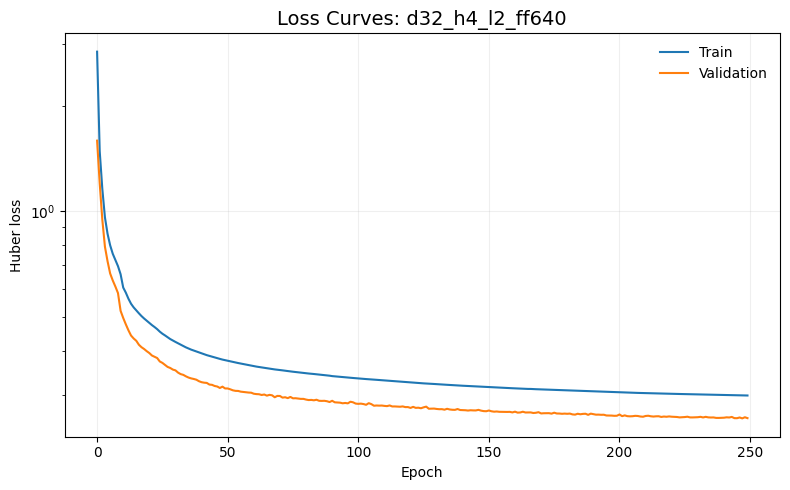

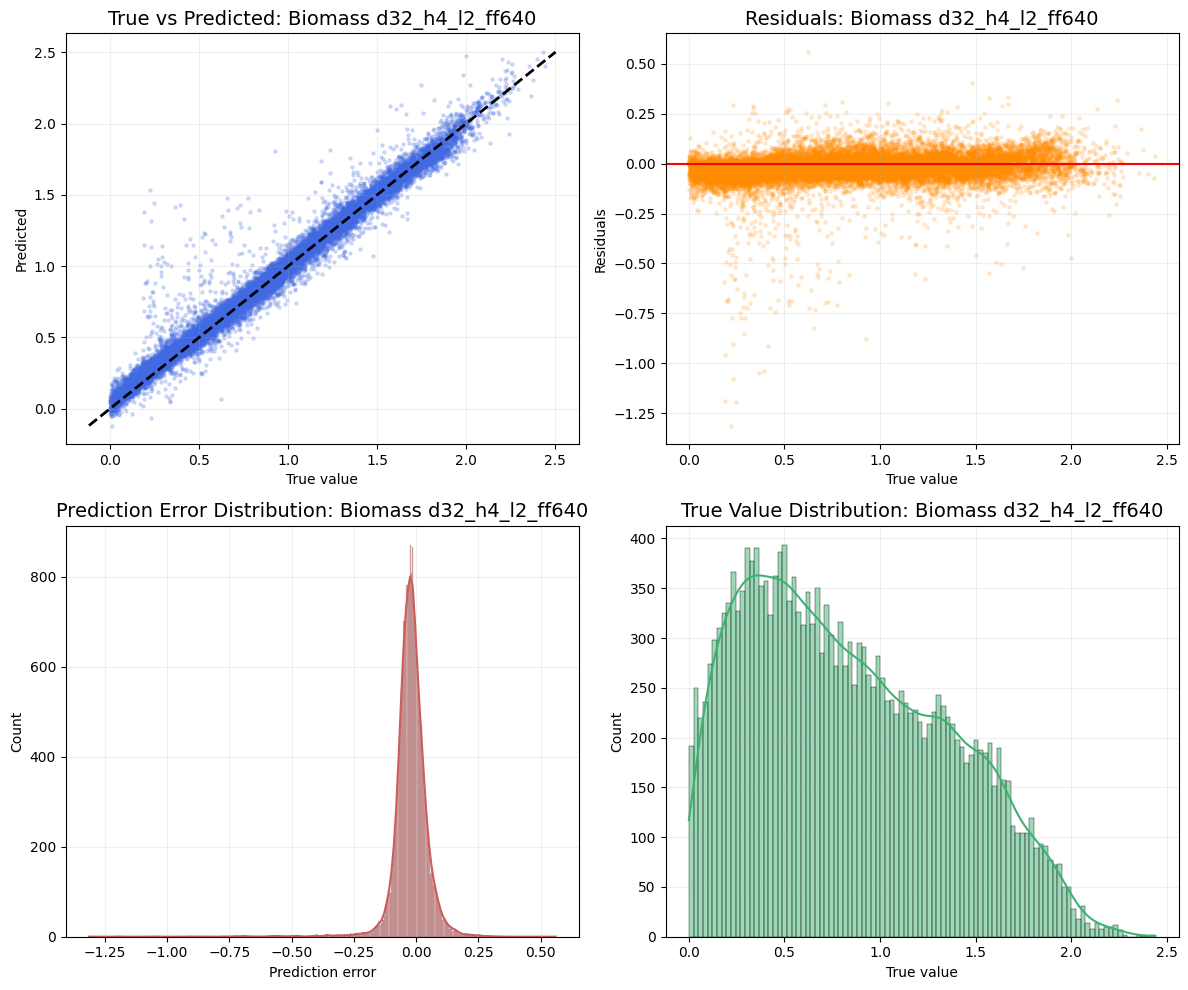

,name,d_model,n_heads,n_layers,d_ff,n_params,best_epoch,best_val_loss,epochs_ran,elapsed_sec,overall_r2,overall_mae,overall_rmse,biomass_r2,biomass_mae,biomass_rmse
0,d32_h4_l2_ff640,32,4,2,640,97582,248,0.256544,250,28137.924446,0.982337,0.387795,1.559937,0.978653,0.047842,0.075814


d32_h4_l2_ff640 | overall R2=0.9823 | MAE=0.387795 | RMSE=1.559937 | biomass R2=0.9787
Cooling down for 1.00 hour(s)...


{'name': 'd32_h4_l2_ff640',
 'd_model': 32,
 'n_heads': 4,
 'n_layers': 2,
 'd_ff': 640,
 'n_params': 97582,
 'best_epoch': 248,
 'best_val_loss': 0.25654379749298095,
 'epochs_ran': 250,
 'elapsed_sec': 28137.924446105957,
 'overall_r2': 0.9823370331255556,
 'overall_mae': 0.38779520689455843,
 'overall_rmse': 1.559937285455846,
 'biomass_r2': 0.9786529541015625,
 'biomass_mae': 0.04784189909696579,
 'biomass_rmse': 0.07581371068954468}

In [7]:
run_model_config(MODEL_CONFIGS[0])  # d32_h4_l2_ff640

Training d128_h8_l2_ff640
Parameters: 477,078
d128_h8_l2_ff640 | epoch 001/250 | train=1.688558 | val=0.787648 | best=0.787648 @ 1 | no_improve=0 | elapsed=00:02:48
d128_h8_l2_ff640 | epoch 002/250 | train=0.710294 | val=0.504868 | best=0.504868 @ 2 | no_improve=0 | elapsed=00:05:46
d128_h8_l2_ff640 | epoch 003/250 | train=0.539963 | val=0.424495 | best=0.424495 @ 3 | no_improve=0 | elapsed=00:08:57
d128_h8_l2_ff640 | epoch 004/250 | train=0.472844 | val=0.391207 | best=0.391207 @ 4 | no_improve=0 | elapsed=00:12:20
d128_h8_l2_ff640 | epoch 005/250 | train=0.439128 | val=0.365901 | best=0.365901 @ 5 | no_improve=0 | elapsed=00:15:54
d128_h8_l2_ff640 | epoch 006/250 | train=0.416467 | val=0.348638 | best=0.348638 @ 6 | no_improve=0 | elapsed=00:19:32
d128_h8_l2_ff640 | epoch 007/250 | train=0.399833 | val=0.338698 | best=0.338698 @ 7 | no_improve=0 | elapsed=00:23:14
d128_h8_l2_ff640 | epoch 008/250 | train=0.385793 | val=0.328558 | best=0.328558 @ 8 | no_improve=0 | elapsed=00:27:00
d1

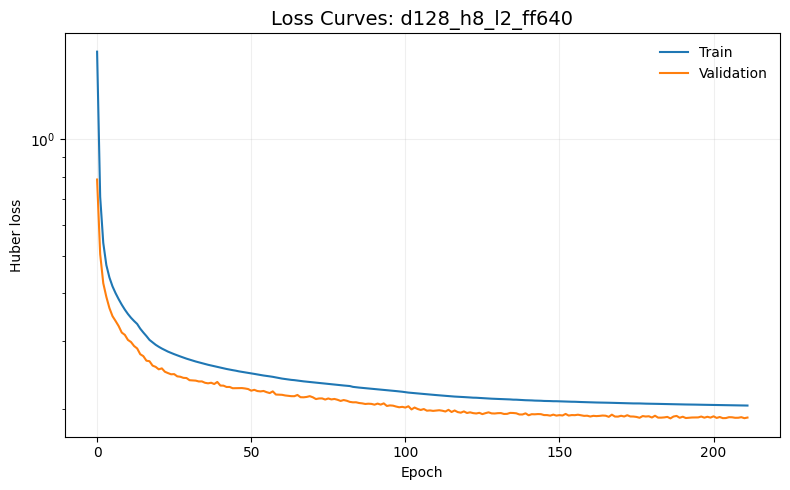

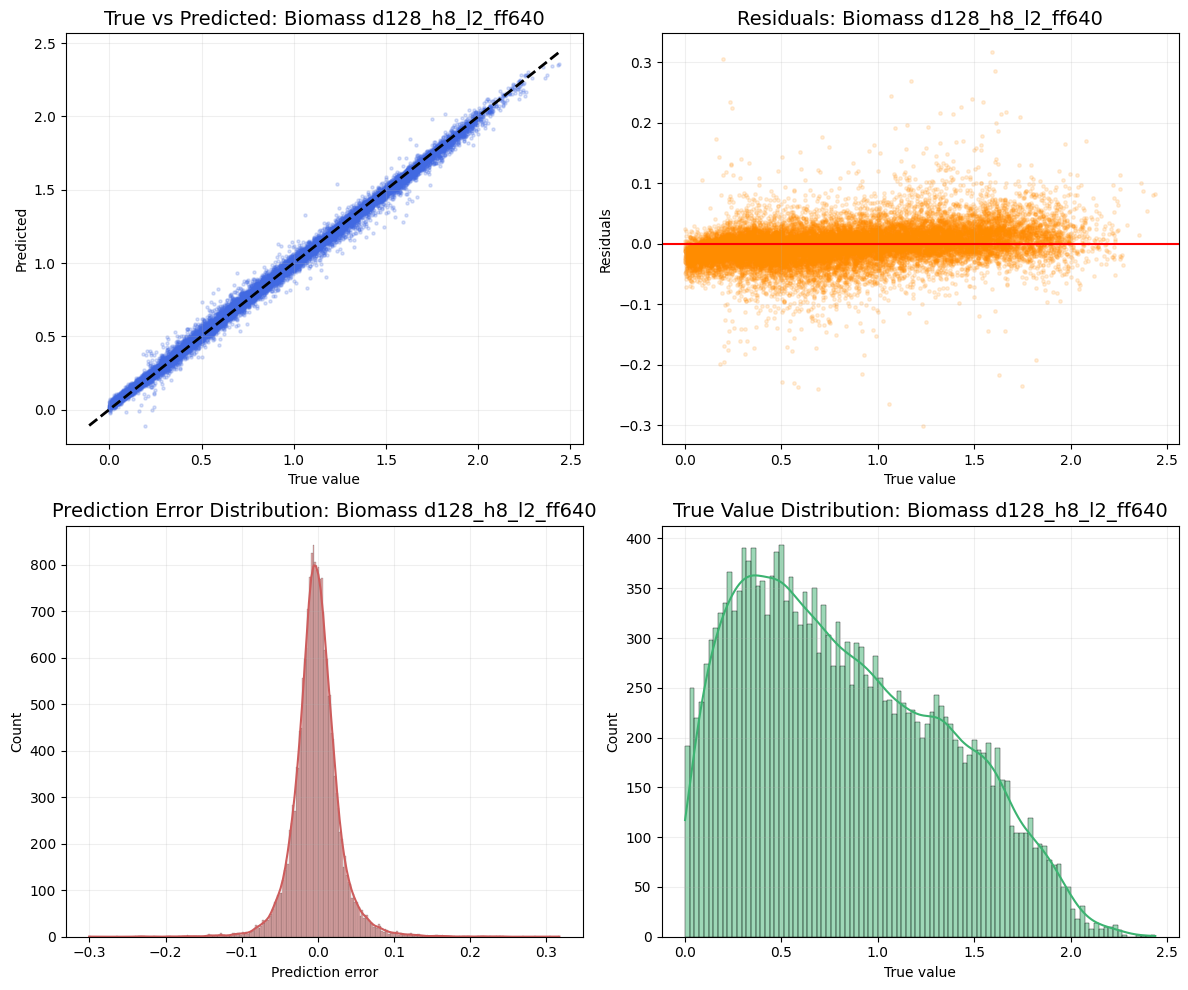

,name,d_model,n_heads,n_layers,d_ff,n_params,best_epoch,best_val_loss,epochs_ran,elapsed_sec,overall_r2,overall_mae,overall_rmse,biomass_r2,biomass_mae,biomass_rmse
0,d32_h4_l2_ff640,32,4,2,640,97582,248,0.256544,250,28137.924446,0.982337,0.387795,1.559937,0.978653,0.047842,0.075814
1,d128_h8_l2_ff640,128,8,2,640,477078,187,0.189484,212,53508.435309,0.987957,0.278610,1.288066,0.996483,0.021238,0.030773


d128_h8_l2_ff640 | overall R2=0.9880 | MAE=0.278610 | RMSE=1.288066 | biomass R2=0.9965
Cooling down for 1.00 hour(s)...


{'name': 'd128_h8_l2_ff640',
 'd_model': 128,
 'n_heads': 8,
 'n_layers': 2,
 'd_ff': 640,
 'n_params': 477078,
 'best_epoch': 187,
 'best_val_loss': 0.18948357000350952,
 'epochs_ran': 212,
 'elapsed_sec': 53508.435309410095,
 'overall_r2': 0.9879572486264836,
 'overall_mae': 0.27860999756930943,
 'overall_rmse': 1.2880661628453824,
 'biomass_r2': 0.9964828491210938,
 'biomass_mae': 0.021238479763269424,
 'biomass_rmse': 0.030773302540183067}

In [8]:
run_model_config(MODEL_CONFIGS[1])  # d128_h8_l2_ff640

Training d64_h8_l3_ff640
Parameters: 308,513
d64_h8_l3_ff640 | epoch 001/250 | train=2.229333 | val=0.973381 | best=0.973381 @ 1 | no_improve=0 | elapsed=00:03:15
d64_h8_l3_ff640 | epoch 002/250 | train=0.871017 | val=0.613849 | best=0.613849 @ 2 | no_improve=0 | elapsed=00:06:57
d64_h8_l3_ff640 | epoch 003/250 | train=0.623991 | val=0.462091 | best=0.462091 @ 3 | no_improve=0 | elapsed=00:11:08
d64_h8_l3_ff640 | epoch 004/250 | train=0.502479 | val=0.384150 | best=0.384150 @ 4 | no_improve=0 | elapsed=00:15:41
d64_h8_l3_ff640 | epoch 005/250 | train=0.442280 | val=0.352733 | best=0.352733 @ 5 | no_improve=0 | elapsed=00:20:19
d64_h8_l3_ff640 | epoch 006/250 | train=0.403533 | val=0.316795 | best=0.316795 @ 6 | no_improve=0 | elapsed=00:25:06
d64_h8_l3_ff640 | epoch 007/250 | train=0.374953 | val=0.297930 | best=0.297930 @ 7 | no_improve=0 | elapsed=00:29:52
d64_h8_l3_ff640 | epoch 008/250 | train=0.349082 | val=0.275112 | best=0.275112 @ 8 | no_improve=0 | elapsed=00:34:44
d64_h8_l3_f

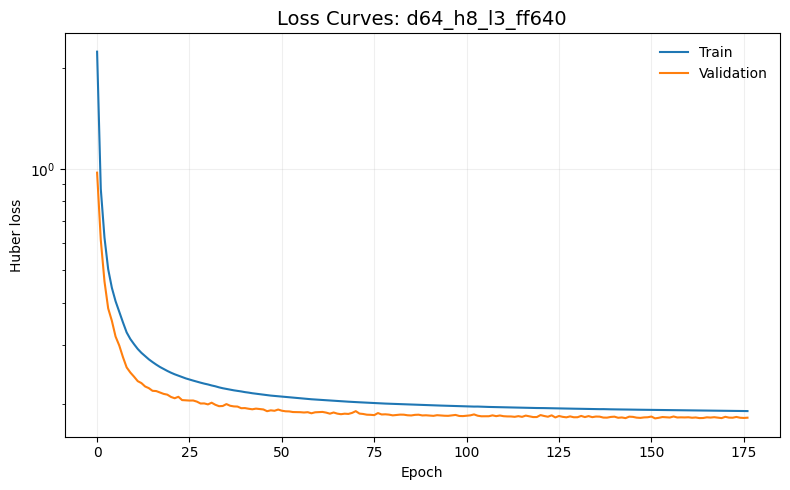

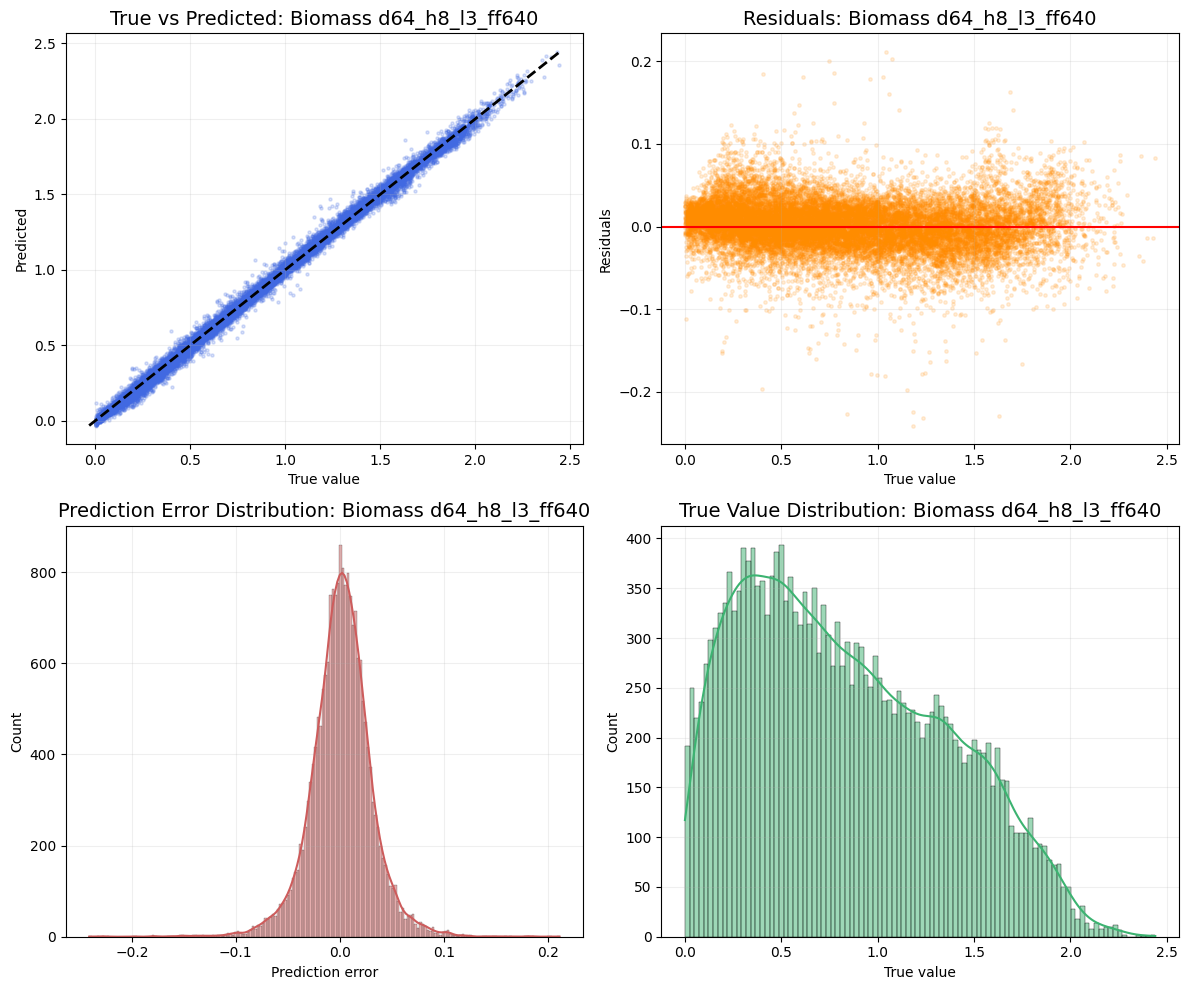

,name,d_model,n_heads,n_layers,d_ff,n_params,best_epoch,best_val_loss,epochs_ran,elapsed_sec,overall_r2,overall_mae,overall_rmse,biomass_r2,biomass_mae,biomass_rmse
0,d32_h4_l2_ff640,32,4,2,640,97582,248,0.256544,250,28137.924446,0.982337,0.387795,1.559937,0.978653,0.047842,0.075814
1,d128_h8_l2_ff640,128,8,2,640,477078,187,0.189484,212,53508.435309,0.987957,0.278610,1.288066,0.996483,0.021238,0.030773
2,d64_h8_l3_ff640,64,8,3,640,308513,152,0.180872,177,50630.256338,0.988036,0.257155,1.283837,0.996712,0.021729,0.029755


d64_h8_l3_ff640 | overall R2=0.9880 | MAE=0.257155 | RMSE=1.283837 | biomass R2=0.9967
Cooling down for 1.00 hour(s)...


{'name': 'd64_h8_l3_ff640',
 'd_model': 64,
 'n_heads': 8,
 'n_layers': 3,
 'd_ff': 640,
 'n_params': 308513,
 'best_epoch': 152,
 'best_val_loss': 0.18087243571281433,
 'epochs_ran': 177,
 'elapsed_sec': 50630.25633788109,
 'overall_r2': 0.988036205556665,
 'overall_mae': 0.25715482923838046,
 'overall_rmse': 1.2838366892541406,
 'biomass_r2': 0.9967117309570312,
 'biomass_mae': 0.021728863939642906,
 'biomass_rmse': 0.02975519374012947}

In [9]:
run_model_config(MODEL_CONFIGS[2])  # d64_h8_l3_ff640

Training d64_h8_l4_ff640
Parameters: 409,324
d64_h8_l4_ff640 | epoch 001/250 | train=2.720524 | val=1.003116 | best=1.003116 @ 1 | no_improve=0 | elapsed=00:04:22
d64_h8_l4_ff640 | epoch 002/250 | train=0.859226 | val=0.619163 | best=0.619163 @ 2 | no_improve=0 | elapsed=00:09:25
d64_h8_l4_ff640 | epoch 003/250 | train=0.617694 | val=0.446693 | best=0.446693 @ 3 | no_improve=0 | elapsed=00:15:02
d64_h8_l4_ff640 | epoch 004/250 | train=0.468672 | val=0.351898 | best=0.351898 @ 4 | no_improve=0 | elapsed=00:21:01
d64_h8_l4_ff640 | epoch 005/250 | train=0.402586 | val=0.312789 | best=0.312789 @ 5 | no_improve=0 | elapsed=00:27:09
d64_h8_l4_ff640 | epoch 006/250 | train=0.363194 | val=0.287627 | best=0.287627 @ 6 | no_improve=0 | elapsed=00:33:22
d64_h8_l4_ff640 | epoch 007/250 | train=0.339012 | val=0.275712 | best=0.275712 @ 7 | no_improve=0 | elapsed=00:39:40
d64_h8_l4_ff640 | epoch 008/250 | train=0.321384 | val=0.265536 | best=0.265536 @ 8 | no_improve=0 | elapsed=00:46:05
d64_h8_l4_f

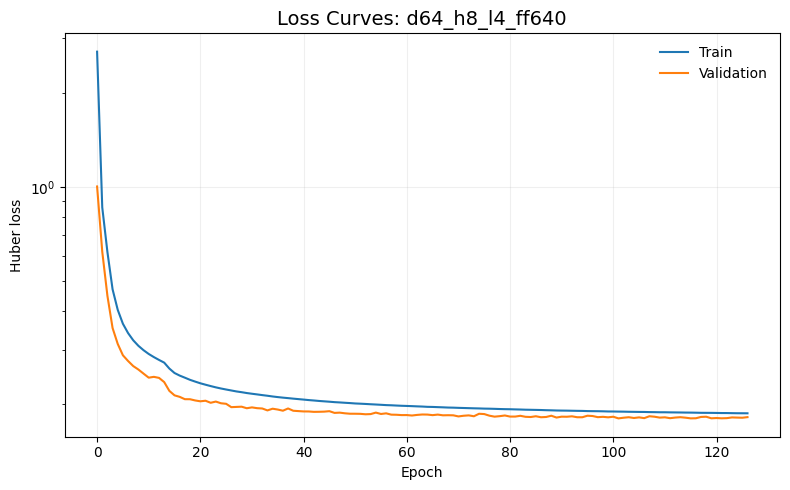

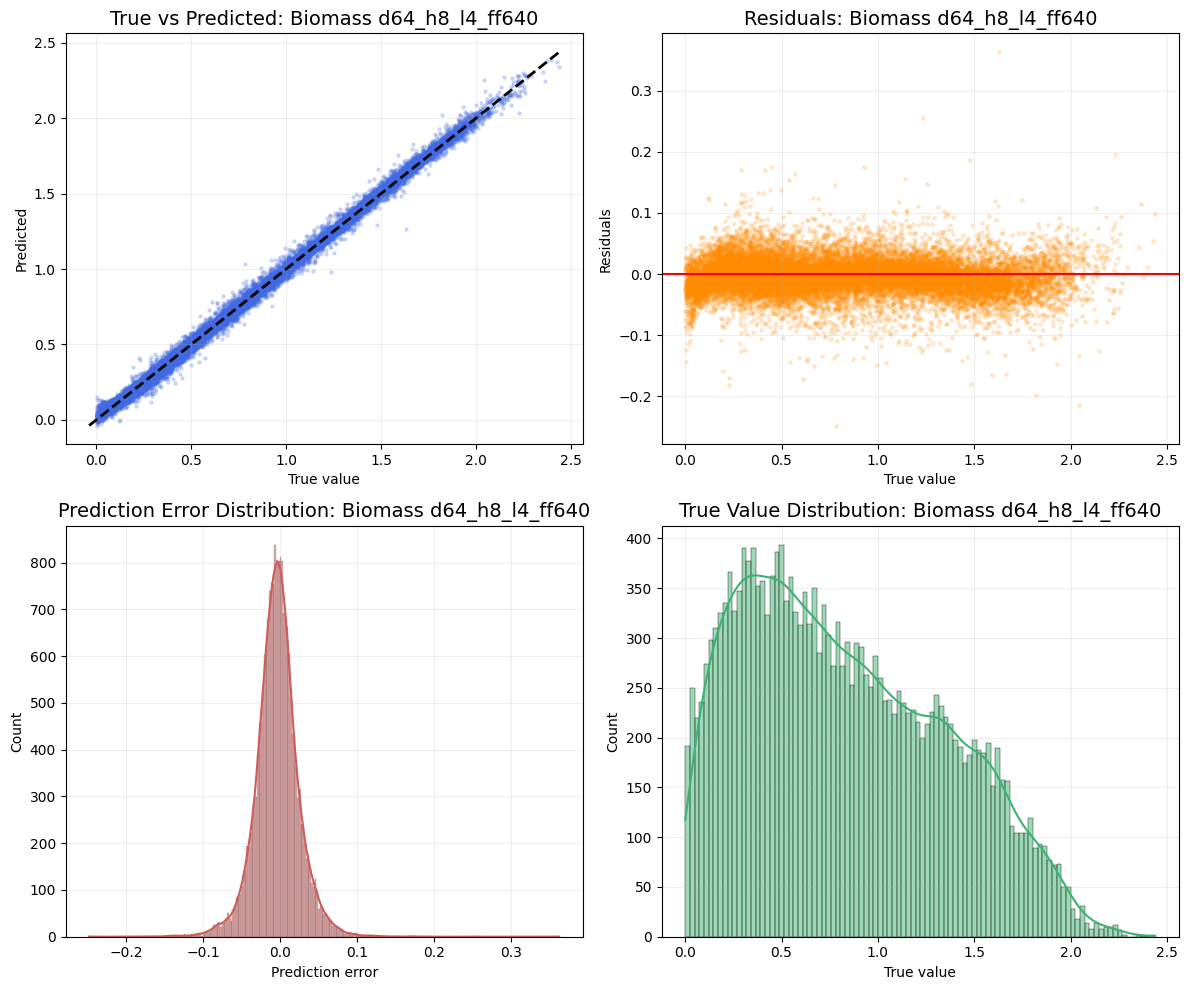

,name,d_model,n_heads,n_layers,d_ff,n_params,best_epoch,best_val_loss,epochs_ran,elapsed_sec,overall_r2,overall_mae,overall_rmse,biomass_r2,biomass_mae,biomass_rmse
0,d32_h4_l2_ff640,32,4,2,640,97582,248,0.256544,250,28137.924446,0.982337,0.387795,1.559937,0.978653,0.047842,0.075814
1,d128_h8_l2_ff640,128,8,2,640,477078,187,0.189484,212,53508.435309,0.987957,0.278610,1.288066,0.996483,0.021238,0.030773
2,d64_h8_l3_ff640,64,8,3,640,308513,152,0.180872,177,50630.256338,0.988036,0.257155,1.283837,0.996712,0.021729,0.029755
3,d64_h8_l4_ff640,64,8,4,640,409324,102,0.180297,127,48089.192041,0.988041,0.254527,1.283606,0.996929,0.020923,0.028755


d64_h8_l4_ff640 | overall R2=0.9880 | MAE=0.254527 | RMSE=1.283606 | biomass R2=0.9969
Cooling down for 1.00 hour(s)...


{'name': 'd64_h8_l4_ff640',
 'd_model': 64,
 'n_heads': 8,
 'n_layers': 4,
 'd_ff': 640,
 'n_params': 409324,
 'best_epoch': 102,
 'best_val_loss': 0.18029655919075013,
 'epochs_ran': 127,
 'elapsed_sec': 48089.192041158676,
 'overall_r2': 0.9880405030614275,
 'overall_mae': 0.2545269568480724,
 'overall_rmse': 1.2836060855829077,
 'biomass_r2': 0.9969291090965271,
 'biomass_mae': 0.020922571420669556,
 'biomass_rmse': 0.028754889965057373}

In [10]:
run_model_config(MODEL_CONFIGS[3])  # d64_h8_l4_ff640

Training d128_h8_l3_ff640
Parameters: 709,537
d128_h8_l3_ff640 | epoch 001/250 | train=1.576458 | val=0.582469 | best=0.582469 @ 1 | no_improve=0 | elapsed=00:04:13
d128_h8_l3_ff640 | epoch 002/250 | train=0.509093 | val=0.363193 | best=0.363193 @ 2 | no_improve=0 | elapsed=00:09:01
d128_h8_l3_ff640 | epoch 003/250 | train=0.387080 | val=0.304718 | best=0.304718 @ 3 | no_improve=0 | elapsed=00:14:32
d128_h8_l3_ff640 | epoch 004/250 | train=0.335927 | val=0.267471 | best=0.267471 @ 4 | no_improve=0 | elapsed=00:20:32
d128_h8_l3_ff640 | epoch 005/250 | train=0.304010 | val=0.253243 | best=0.253243 @ 5 | no_improve=0 | elapsed=00:26:32
d128_h8_l3_ff640 | epoch 006/250 | train=0.283226 | val=0.234085 | best=0.234085 @ 6 | no_improve=0 | elapsed=00:32:37
d128_h8_l3_ff640 | epoch 007/250 | train=0.269109 | val=0.224978 | best=0.224978 @ 7 | no_improve=0 | elapsed=00:38:49
d128_h8_l3_ff640 | epoch 008/250 | train=0.259292 | val=0.217482 | best=0.217482 @ 8 | no_improve=0 | elapsed=00:45:01
d1

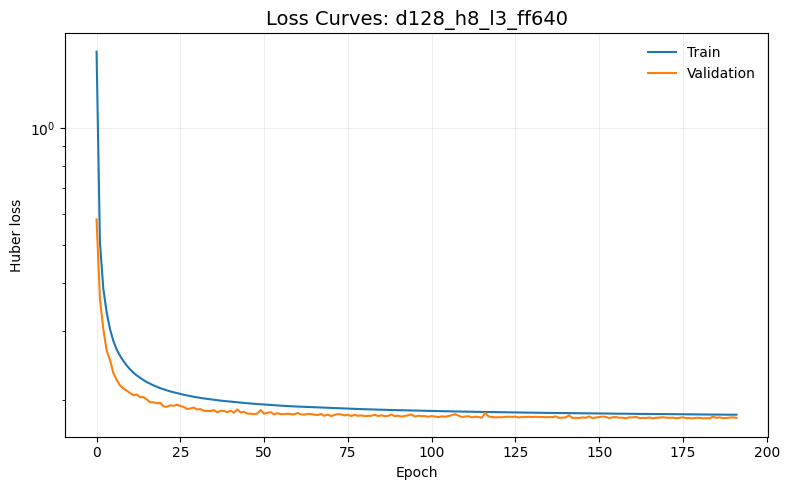

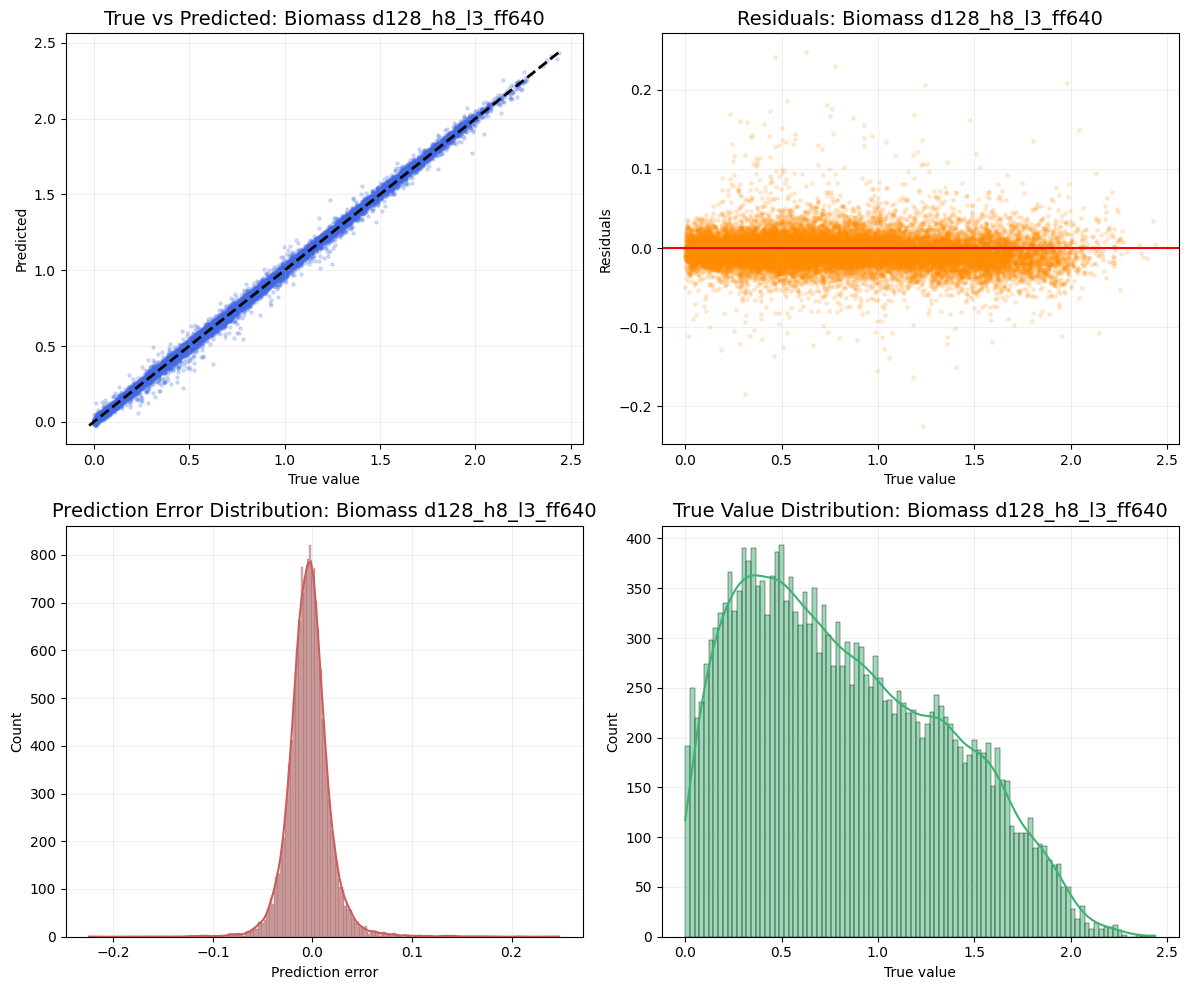

,name,d_model,n_heads,n_layers,d_ff,n_params,best_epoch,best_val_loss,epochs_ran,elapsed_sec,overall_r2,overall_mae,overall_rmse,biomass_r2,biomass_mae,biomass_rmse
0,d32_h4_l2_ff640,32,4,2,640,97582,248,0.256544,250,28137.924446,0.982337,0.387795,1.559937,0.978653,0.047842,0.075814
1,d128_h8_l2_ff640,128,8,2,640,477078,187,0.189484,212,53508.435309,0.987957,0.278610,1.288066,0.996483,0.021238,0.030773
2,d64_h8_l3_ff640,64,8,3,640,308513,152,0.180872,177,50630.256338,0.988036,0.257155,1.283837,0.996712,0.021729,0.029755
3,d64_h8_l4_ff640,64,8,4,640,409324,102,0.180297,127,48089.192041,0.988041,0.254527,1.283606,0.996929,0.020923,0.028755
4,d128_h8_l3_ff640,128,8,3,640,709537,179,0.178809,192,73210.241802,0.987977,0.248456,1.287000,0.998204,0.015349,0.021993


d128_h8_l3_ff640 | overall R2=0.9880 | MAE=0.248456 | RMSE=1.287000 | biomass R2=0.9982
Cooling down for 1.00 hour(s)...


{'name': 'd128_h8_l3_ff640',
 'd_model': 128,
 'n_heads': 8,
 'n_layers': 3,
 'd_ff': 640,
 'n_params': 709537,
 'best_epoch': 179,
 'best_val_loss': 0.1788087230205536,
 'epochs_ran': 192,
 'elapsed_sec': 73210.24180221558,
 'overall_r2': 0.9879771846586356,
 'overall_mae': 0.24845622479756757,
 'overall_rmse': 1.2869995641954641,
 'biomass_r2': 0.9982036352157593,
 'biomass_mae': 0.01534937135875225,
 'biomass_rmse': 0.02199261449277401}

In [11]:
run_model_config(MODEL_CONFIGS[4])  # d128_h8_l3_ff640

Training d128_h8_l3_ff1024
Parameters: 1,007,905
d128_h8_l3_ff1024 | epoch 001/250 | train=1.566743 | val=0.607822 | best=0.607822 @ 1 | no_improve=0 | elapsed=00:05:03
d128_h8_l3_ff1024 | epoch 002/250 | train=0.544776 | val=0.389072 | best=0.389072 @ 2 | no_improve=0 | elapsed=00:11:28
d128_h8_l3_ff1024 | epoch 003/250 | train=0.416168 | val=0.325280 | best=0.325280 @ 3 | no_improve=0 | elapsed=00:18:43
d128_h8_l3_ff1024 | epoch 004/250 | train=0.360558 | val=0.289278 | best=0.289278 @ 4 | no_improve=0 | elapsed=00:26:18
d128_h8_l3_ff1024 | epoch 005/250 | train=0.322907 | val=0.258875 | best=0.258875 @ 5 | no_improve=0 | elapsed=00:34:03
d128_h8_l3_ff1024 | epoch 006/250 | train=0.298215 | val=0.250970 | best=0.250970 @ 6 | no_improve=0 | elapsed=00:41:49
d128_h8_l3_ff1024 | epoch 007/250 | train=0.282326 | val=0.238750 | best=0.238750 @ 7 | no_improve=0 | elapsed=00:49:31
d128_h8_l3_ff1024 | epoch 008/250 | train=0.270371 | val=0.233708 | best=0.233708 @ 8 | no_improve=0 | elapsed=

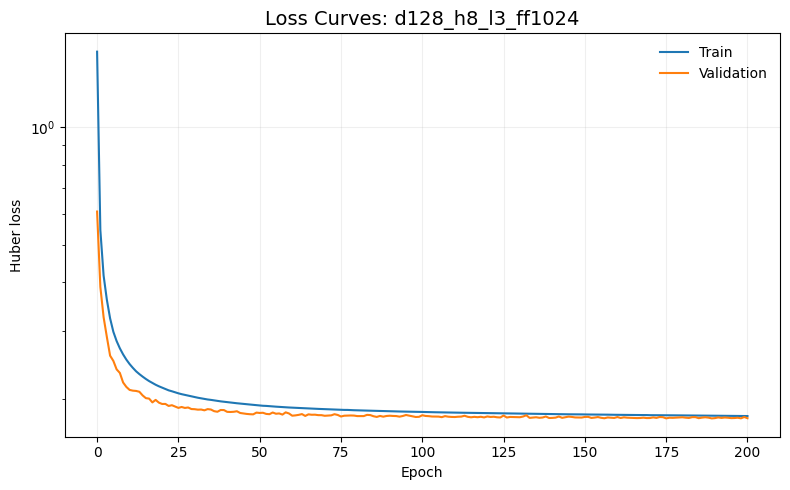

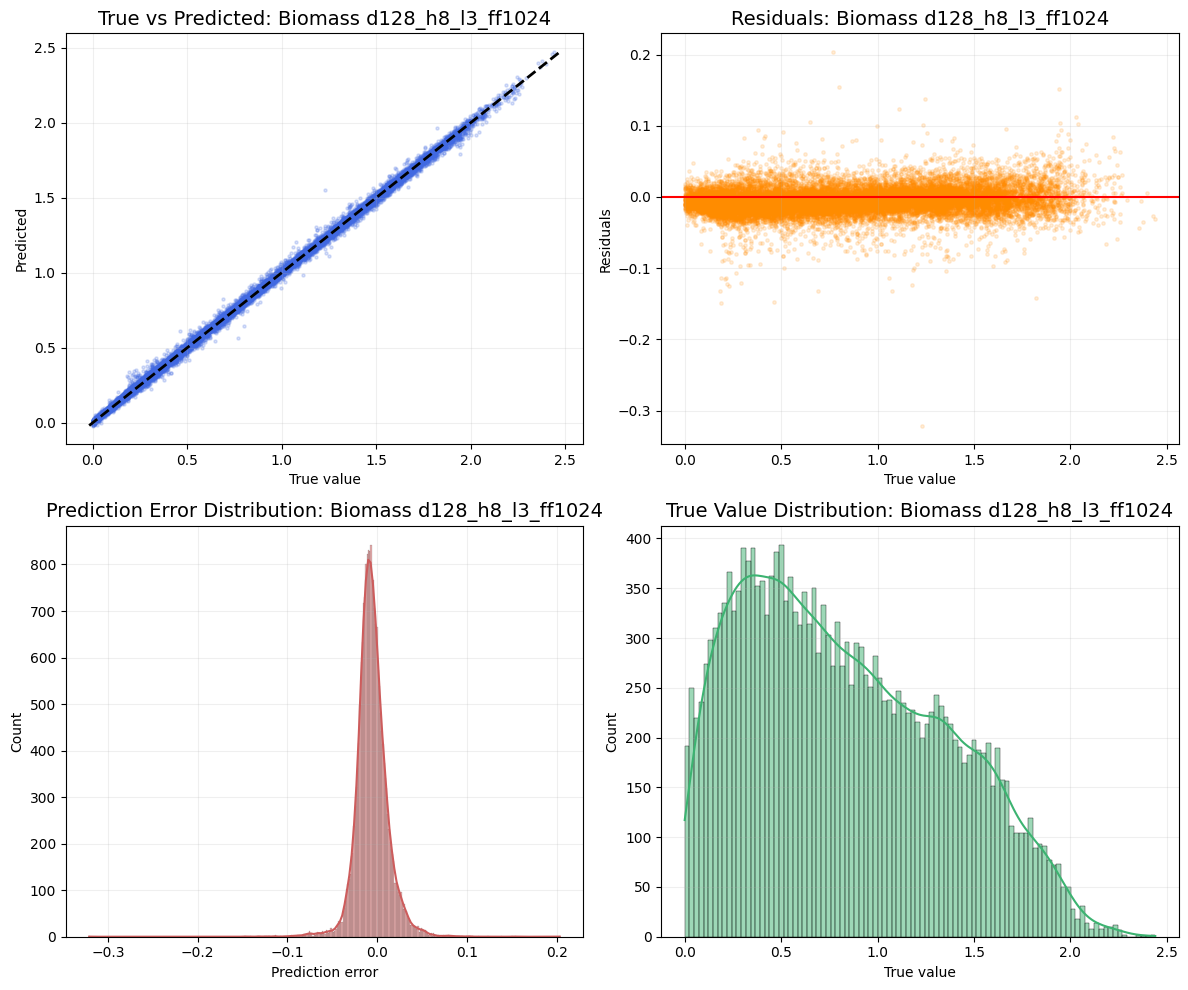

,name,d_model,n_heads,n_layers,d_ff,n_params,best_epoch,best_val_loss,epochs_ran,elapsed_sec,overall_r2,overall_mae,overall_rmse,biomass_r2,biomass_mae,biomass_rmse
0,d32_h4_l2_ff640,32,4,2,640,97582,248,0.256544,250,28137.924446,0.982337,0.387795,1.559937,0.978653,0.047842,0.075814
1,d128_h8_l2_ff640,128,8,2,640,477078,187,0.189484,212,53508.435309,0.987957,0.278610,1.288066,0.996483,0.021238,0.030773
2,d64_h8_l3_ff640,64,8,3,640,308513,152,0.180872,177,50630.256338,0.988036,0.257155,1.283837,0.996712,0.021729,0.029755
3,d64_h8_l4_ff640,64,8,4,640,409324,102,0.180297,127,48089.192041,0.988041,0.254527,1.283606,0.996929,0.020923,0.028755
4,d128_h8_l3_ff640,128,8,3,640,709537,179,0.178809,192,73210.241802,0.987977,0.248456,1.287000,0.998204,0.015349,0.021993
5,d128_h8_l3_ff1024,128,8,3,1024,1007905,190,0.178555,201,98713.044263,0.987966,0.246936,1.287588,0.998691,0.013814,0.018771


d128_h8_l3_ff1024 | overall R2=0.9880 | MAE=0.246936 | RMSE=1.287588 | biomass R2=0.9987
Cooling down for 1.00 hour(s)...


{'name': 'd128_h8_l3_ff1024',
 'd_model': 128,
 'n_heads': 8,
 'n_layers': 3,
 'd_ff': 1024,
 'n_params': 1007905,
 'best_epoch': 190,
 'best_val_loss': 0.1785550563097,
 'epochs_ran': 201,
 'elapsed_sec': 98713.04426312447,
 'overall_r2': 0.9879661950965795,
 'overall_mae': 0.24693647940830196,
 'overall_rmse': 1.287587626585154,
 'biomass_r2': 0.9986913800239563,
 'biomass_mae': 0.013814088888466358,
 'biomass_rmse': 0.018770907074213028}

In [12]:
run_model_config(MODEL_CONFIGS[5])  # d128_h8_l3_ff1024

Training d128_h8_l4_ff640
Parameters: 941,996
d128_h8_l4_ff640 | epoch 001/250 | train=2.079836 | val=0.634267 | best=0.634267 @ 1 | no_improve=0 | elapsed=00:05:54
d128_h8_l4_ff640 | epoch 002/250 | train=0.528044 | val=0.360442 | best=0.360442 @ 2 | no_improve=0 | elapsed=00:14:00
d128_h8_l4_ff640 | epoch 003/250 | train=0.380832 | val=0.285851 | best=0.285851 @ 3 | no_improve=0 | elapsed=00:23:06
d128_h8_l4_ff640 | epoch 004/250 | train=0.321790 | val=0.253904 | best=0.253904 @ 4 | no_improve=0 | elapsed=00:32:18
d128_h8_l4_ff640 | epoch 005/250 | train=0.289958 | val=0.238487 | best=0.238487 @ 5 | no_improve=0 | elapsed=00:41:45
d128_h8_l4_ff640 | epoch 006/250 | train=0.271182 | val=0.227970 | best=0.227970 @ 6 | no_improve=0 | elapsed=00:51:08
d128_h8_l4_ff640 | epoch 007/250 | train=0.257764 | val=0.224354 | best=0.224354 @ 7 | no_improve=0 | elapsed=01:00:33
d128_h8_l4_ff640 | epoch 008/250 | train=0.247686 | val=0.213988 | best=0.213988 @ 8 | no_improve=0 | elapsed=01:10:10
d1

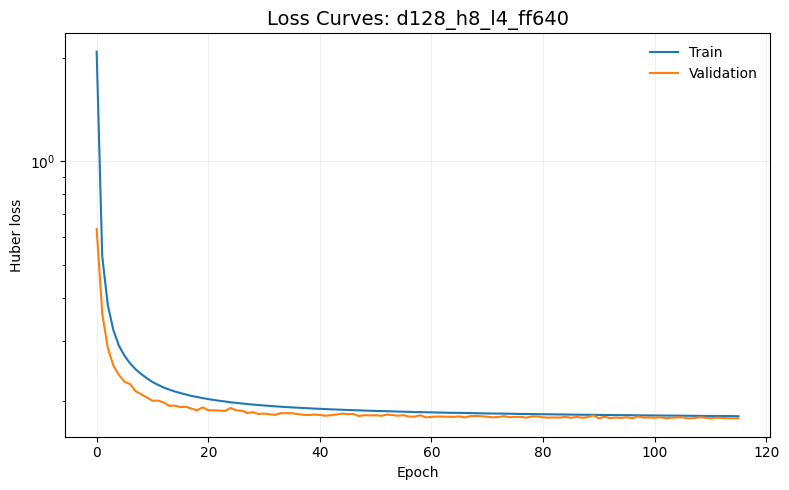

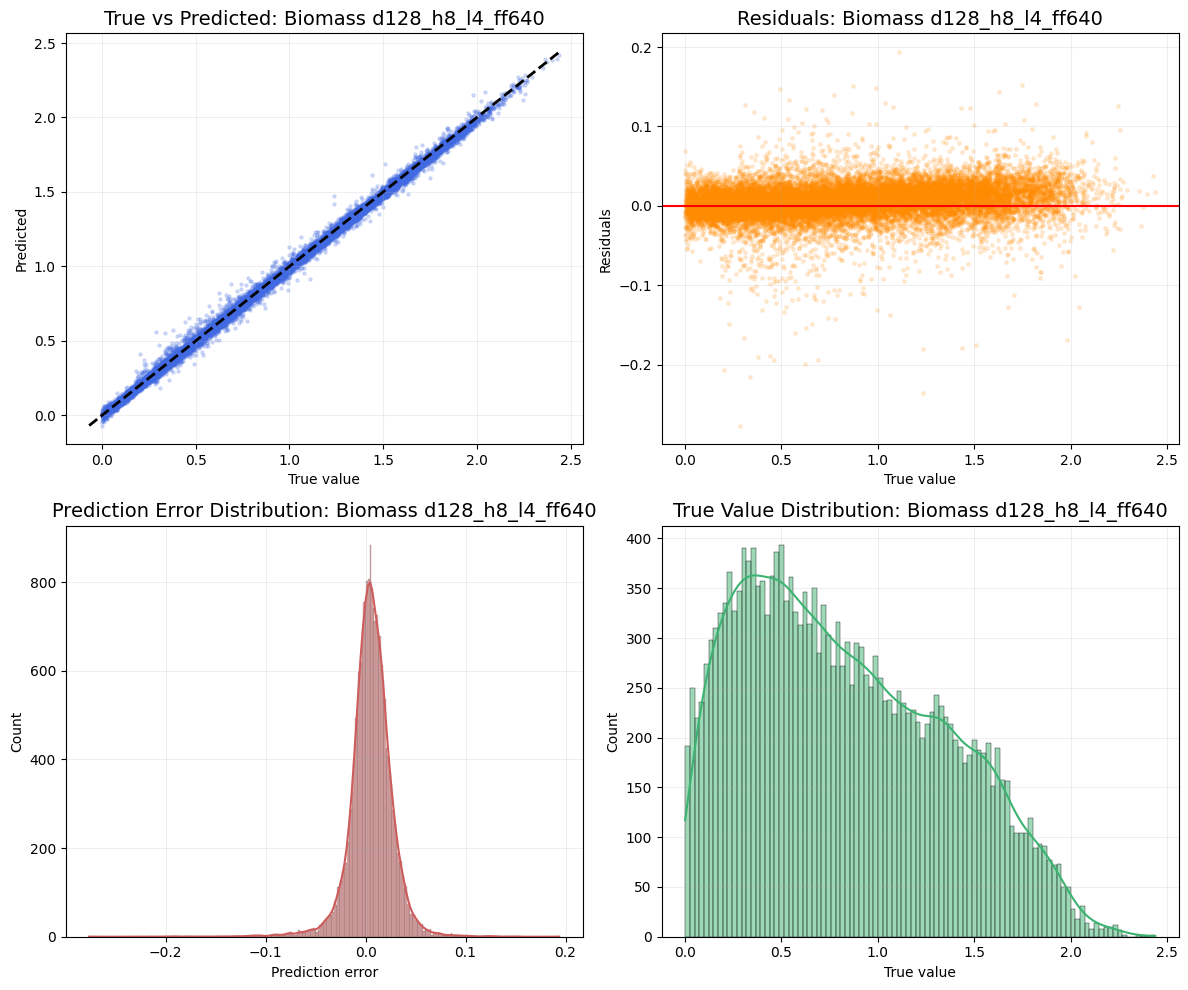

,name,d_model,n_heads,n_layers,d_ff,n_params,best_epoch,best_val_loss,epochs_ran,elapsed_sec,overall_r2,overall_mae,overall_rmse,biomass_r2,biomass_mae,biomass_rmse
0,d32_h4_l2_ff640,32,4,2,640,97582,248,0.256544,250,28137.924446,0.982337,0.387795,1.559937,0.978653,0.047842,0.075814
1,d128_h8_l2_ff640,128,8,2,640,477078,187,0.189484,212,53508.435309,0.987957,0.278610,1.288066,0.996483,0.021238,0.030773
2,d64_h8_l3_ff640,64,8,3,640,308513,152,0.180872,177,50630.256338,0.988036,0.257155,1.283837,0.996712,0.021729,0.029755
3,d64_h8_l4_ff640,64,8,4,640,409324,102,0.180297,127,48089.192041,0.988041,0.254527,1.283606,0.996929,0.020923,0.028755
4,d128_h8_l3_ff640,128,8,3,640,709537,179,0.178809,192,73210.241802,0.987977,0.248456,1.287000,0.998204,0.015349,0.021993
5,d128_h8_l3_ff1024,128,8,3,1024,1007905,190,0.178555,201,98713.044263,0.987966,0.246936,1.287588,0.998691,0.013814,0.018771
6,d128_h8_l4_ff640,128,8,4,640,941996,107,0.178388,116,63297.518159,0.988034,0.247871,1.283937,0.998118,0.015807,0.022513


d128_h8_l4_ff640 | overall R2=0.9880 | MAE=0.247871 | RMSE=1.283937 | biomass R2=0.9981
Cooling down for 1.00 hour(s)...


{'name': 'd128_h8_l4_ff640',
 'd_model': 128,
 'n_heads': 8,
 'n_layers': 4,
 'd_ff': 640,
 'n_params': 941996,
 'best_epoch': 107,
 'best_val_loss': 0.17838779549598693,
 'epochs_ran': 116,
 'elapsed_sec': 63297.51815891266,
 'overall_r2': 0.9880343325253614,
 'overall_mae': 0.2478714856320383,
 'overall_rmse': 1.2839371829649275,
 'biomass_r2': 0.9981176853179932,
 'biomass_mae': 0.015807397663593292,
 'biomass_rmse': 0.022512521594762802}

In [13]:
run_model_config(MODEL_CONFIGS[6])  # d128_h8_l4_ff640

Training d128_h8_l4_ff1024
Parameters: 1,339,820
d128_h8_l4_ff1024 | epoch 001/250 | train=1.852569 | val=0.587514 | best=0.587514 @ 1 | no_improve=0 | elapsed=00:06:50
d128_h8_l4_ff1024 | epoch 002/250 | train=0.480665 | val=0.316366 | best=0.316366 @ 2 | no_improve=0 | elapsed=00:15:16
d128_h8_l4_ff1024 | epoch 003/250 | train=0.347329 | val=0.276274 | best=0.276274 @ 3 | no_improve=0 | elapsed=00:24:26
d128_h8_l4_ff1024 | epoch 004/250 | train=0.308157 | val=0.252165 | best=0.252165 @ 4 | no_improve=0 | elapsed=00:33:53
d128_h8_l4_ff1024 | epoch 005/250 | train=0.286830 | val=0.241428 | best=0.241428 @ 5 | no_improve=0 | elapsed=00:43:29
d128_h8_l4_ff1024 | epoch 006/250 | train=0.269551 | val=0.223155 | best=0.223155 @ 6 | no_improve=0 | elapsed=00:53:12
d128_h8_l4_ff1024 | epoch 007/250 | train=0.251337 | val=0.216669 | best=0.216669 @ 7 | no_improve=0 | elapsed=01:02:40
d128_h8_l4_ff1024 | epoch 008/250 | train=0.241362 | val=0.207962 | best=0.207962 @ 8 | no_improve=0 | elapsed=

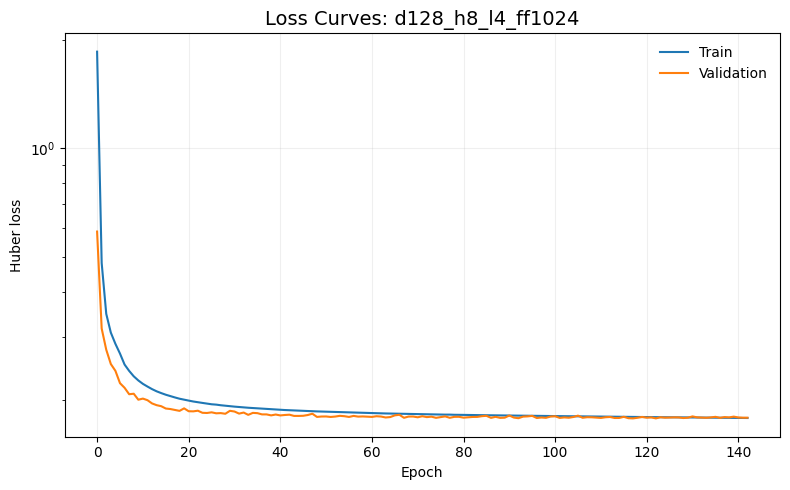

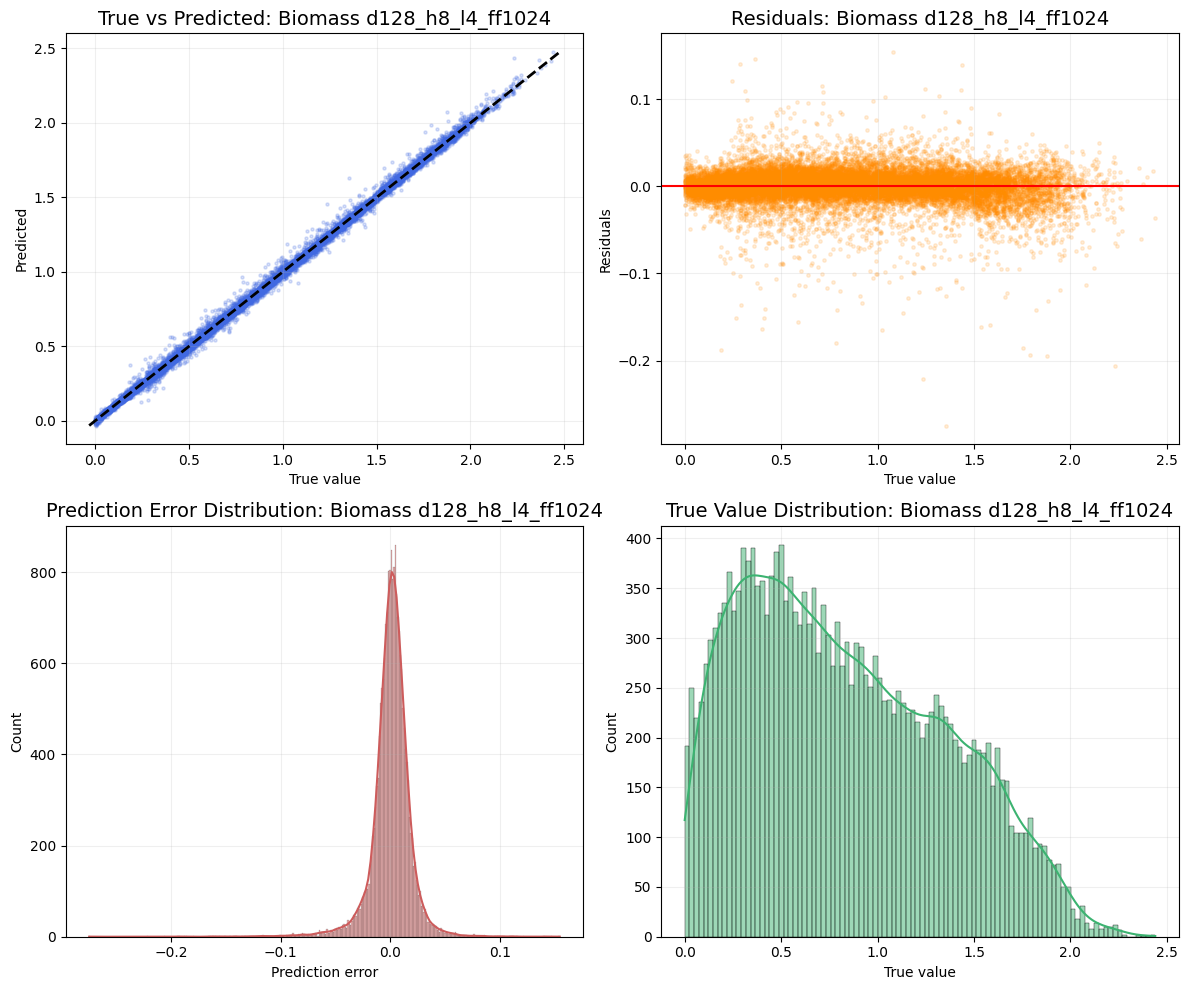

,name,d_model,n_heads,n_layers,d_ff,n_params,best_epoch,best_val_loss,epochs_ran,elapsed_sec,overall_r2,overall_mae,overall_rmse,biomass_r2,biomass_mae,biomass_rmse
0,d32_h4_l2_ff640,32,4,2,640,97582,248,0.256544,250,28137.924446,0.982337,0.387795,1.559937,0.978653,0.047842,0.075814
1,d128_h8_l2_ff640,128,8,2,640,477078,187,0.189484,212,53508.435309,0.987957,0.278610,1.288066,0.996483,0.021238,0.030773
2,d64_h8_l3_ff640,64,8,3,640,308513,152,0.180872,177,50630.256338,0.988036,0.257155,1.283837,0.996712,0.021729,0.029755
3,d64_h8_l4_ff640,64,8,4,640,409324,102,0.180297,127,48089.192041,0.988041,0.254527,1.283606,0.996929,0.020923,0.028755
4,d128_h8_l3_ff640,128,8,3,640,709537,179,0.178809,192,73210.241802,0.987977,0.248456,1.287000,0.998204,0.015349,0.021993
5,d128_h8_l3_ff1024,128,8,3,1024,1007905,190,0.178555,201,98713.044263,0.987966,0.246936,1.287588,0.998691,0.013814,0.018771
6,d128_h8_l4_ff640,128,8,4,640,941996,107,0.178388,116,63297.518159,0.988034,0.247871,1.283937,0.998118,0.015807,0.022513
7,d128_h8_l4_ff1024,128,8,4,1024,1339820,118,0.178233,143,82808.177722,0.988101,0.246746,1.280359,0.998737,0.011941,0.018442


d128_h8_l4_ff1024 | overall R2=0.9881 | MAE=0.246746 | RMSE=1.280359 | biomass R2=0.9987
Cooling down for 1.00 hour(s)...


{'name': 'd128_h8_l4_ff1024',
 'd_model': 128,
 'n_heads': 8,
 'n_layers': 4,
 'd_ff': 1024,
 'n_params': 1339820,
 'best_epoch': 118,
 'best_val_loss': 0.178233371591568,
 'epochs_ran': 143,
 'elapsed_sec': 82808.1777215004,
 'overall_r2': 0.9881009350799264,
 'overall_mae': 0.2467455516959255,
 'overall_rmse': 1.2803589110560418,
 'biomass_r2': 0.9987368583679199,
 'biomass_mae': 0.011940639466047287,
 'biomass_rmse': 0.018442053347826004}

In [14]:
run_model_config(MODEL_CONFIGS[7])  # d128_h8_l4_ff1024

Training d256_h8_l3_ff640
Parameters: 1,806,497
d256_h8_l3_ff640 | epoch 001/250 | train=1.200334 | val=0.428451 | best=0.428451 @ 1 | no_improve=0 | elapsed=00:07:07
d256_h8_l3_ff640 | epoch 002/250 | train=0.426974 | val=0.320213 | best=0.320213 @ 2 | no_improve=0 | elapsed=00:16:25
d256_h8_l3_ff640 | epoch 003/250 | train=0.344748 | val=0.271880 | best=0.271880 @ 3 | no_improve=0 | elapsed=00:26:22
d256_h8_l3_ff640 | epoch 004/250 | train=0.302310 | val=0.247010 | best=0.247010 @ 4 | no_improve=0 | elapsed=00:36:30
d256_h8_l3_ff640 | epoch 005/250 | train=0.275433 | val=0.234882 | best=0.234882 @ 5 | no_improve=0 | elapsed=00:46:46
d256_h8_l3_ff640 | epoch 006/250 | train=0.259184 | val=0.224345 | best=0.224345 @ 6 | no_improve=0 | elapsed=00:56:53
d256_h8_l3_ff640 | epoch 007/250 | train=0.247055 | val=0.213351 | best=0.213351 @ 7 | no_improve=0 | elapsed=01:07:09
d256_h8_l3_ff640 | epoch 008/250 | train=0.238130 | val=0.210705 | best=0.210705 @ 8 | no_improve=0 | elapsed=01:17:22


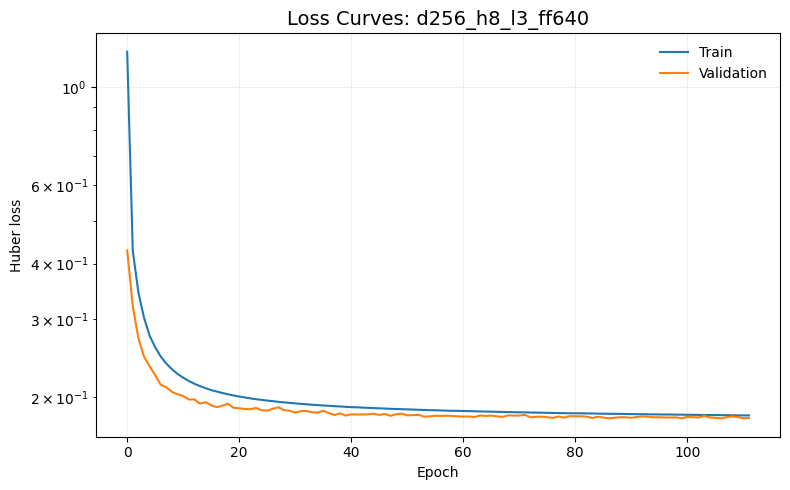

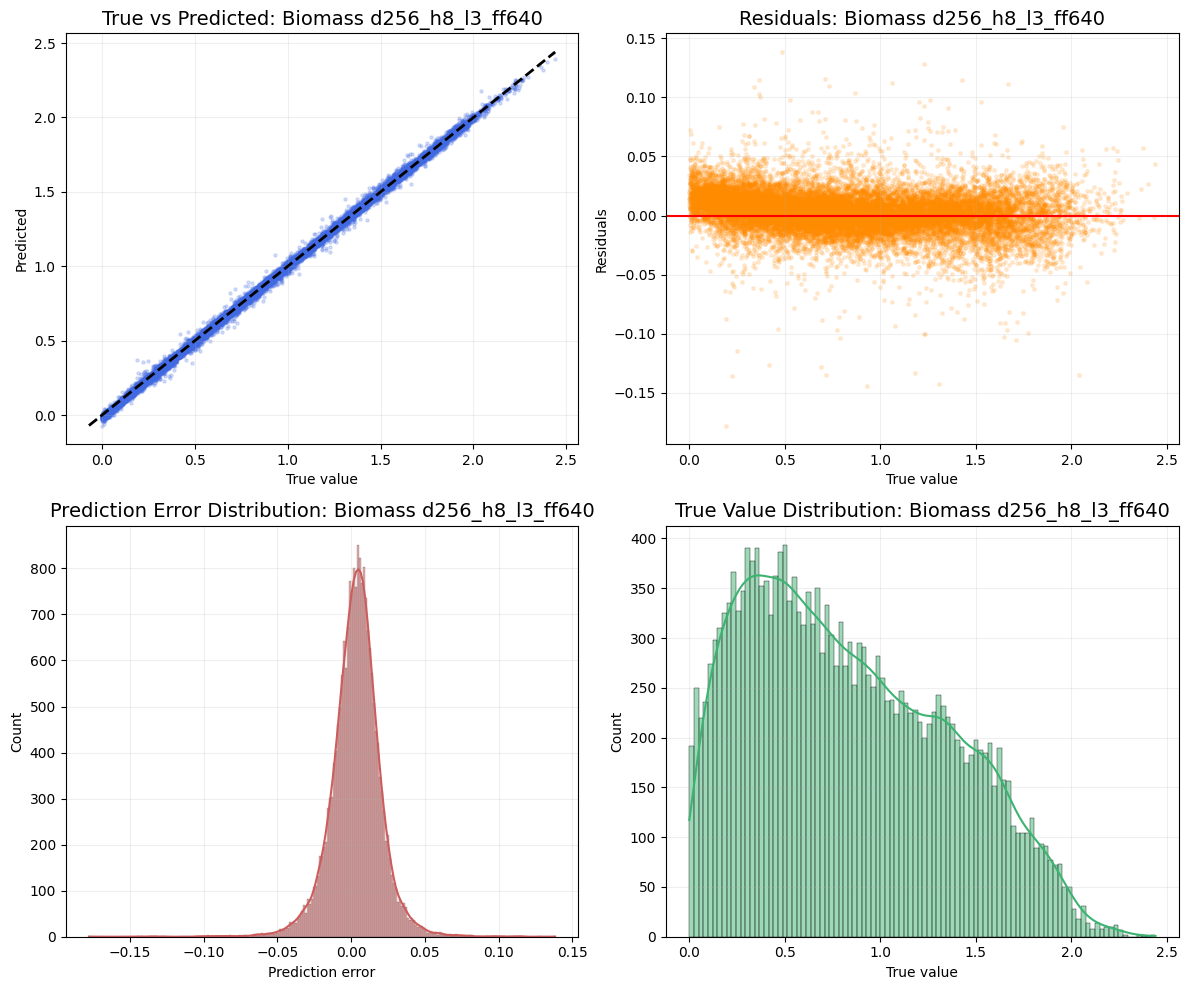

,name,d_model,n_heads,n_layers,d_ff,n_params,best_epoch,best_val_loss,epochs_ran,elapsed_sec,overall_r2,overall_mae,overall_rmse,biomass_r2,biomass_mae,biomass_rmse
0,d32_h4_l2_ff640,32,4,2,640,97582,248,0.256544,250,28137.924446,0.982337,0.387795,1.559937,0.978653,0.047842,0.075814
1,d128_h8_l2_ff640,128,8,2,640,477078,187,0.189484,212,53508.435309,0.987957,0.278610,1.288066,0.996483,0.021238,0.030773
2,d64_h8_l3_ff640,64,8,3,640,308513,152,0.180872,177,50630.256338,0.988036,0.257155,1.283837,0.996712,0.021729,0.029755
3,d64_h8_l4_ff640,64,8,4,640,409324,102,0.180297,127,48089.192041,0.988041,0.254527,1.283606,0.996929,0.020923,0.028755
4,d128_h8_l3_ff640,128,8,3,640,709537,179,0.178809,192,73210.241802,0.987977,0.248456,1.287000,0.998204,0.015349,0.021993
5,d128_h8_l3_ff1024,128,8,3,1024,1007905,190,0.178555,201,98713.044263,0.987966,0.246936,1.287588,0.998691,0.013814,0.018771
6,d128_h8_l4_ff640,128,8,4,640,941996,107,0.178388,116,63297.518159,0.988034,0.247871,1.283937,0.998118,0.015807,0.022513
7,d128_h8_l4_ff1024,128,8,4,1024,1339820,118,0.178233,143,82808.177722,0.988101,0.246746,1.280359,0.998737,0.011941,0.018442
8,d256_h8_l3_ff640,256,8,3,640,1806497,107,0.179311,112,66138.300228,0.987977,0.251683,1.286988,0.998867,0.012733,0.017467


d256_h8_l3_ff640 | overall R2=0.9880 | MAE=0.251683 | RMSE=1.286988 | biomass R2=0.9989
Cooling down for 1.00 hour(s)...


{'name': 'd256_h8_l3_ff640',
 'd_model': 256,
 'n_heads': 8,
 'n_layers': 3,
 'd_ff': 640,
 'n_params': 1806497,
 'best_epoch': 107,
 'best_val_loss': 0.17931127347946166,
 'epochs_ran': 112,
 'elapsed_sec': 66138.3002281189,
 'overall_r2': 0.9879774046022579,
 'overall_mae': 0.25168258162704277,
 'overall_rmse': 1.2869877920508959,
 'biomass_r2': 0.998866856098175,
 'biomass_mae': 0.012733494862914085,
 'biomass_rmse': 0.017467275261878967}

In [15]:
run_model_config(MODEL_CONFIGS[8])  # d256_h8_l3_ff640

Training d256_h8_l3_ff1024
Parameters: 2,399,777
d256_h8_l3_ff1024 | epoch 001/250 | train=1.148290 | val=0.430765 | best=0.430765 @ 1 | no_improve=0 | elapsed=00:08:11
d256_h8_l3_ff1024 | epoch 002/250 | train=0.434054 | val=0.318001 | best=0.318001 @ 2 | no_improve=0 | elapsed=00:18:42
d256_h8_l3_ff1024 | epoch 003/250 | train=0.353838 | val=0.278065 | best=0.278065 @ 3 | no_improve=0 | elapsed=00:29:52
d256_h8_l3_ff1024 | epoch 004/250 | train=0.312907 | val=0.256634 | best=0.256634 @ 4 | no_improve=0 | elapsed=00:41:15
d256_h8_l3_ff1024 | epoch 005/250 | train=0.280482 | val=0.232827 | best=0.232827 @ 5 | no_improve=0 | elapsed=00:52:36
d256_h8_l3_ff1024 | epoch 006/250 | train=0.258986 | val=0.218779 | best=0.218779 @ 6 | no_improve=0 | elapsed=01:03:57
d256_h8_l3_ff1024 | epoch 007/250 | train=0.246346 | val=0.215427 | best=0.215427 @ 7 | no_improve=0 | elapsed=01:15:26
d256_h8_l3_ff1024 | epoch 008/250 | train=0.236994 | val=0.211022 | best=0.211022 @ 8 | no_improve=0 | elapsed=

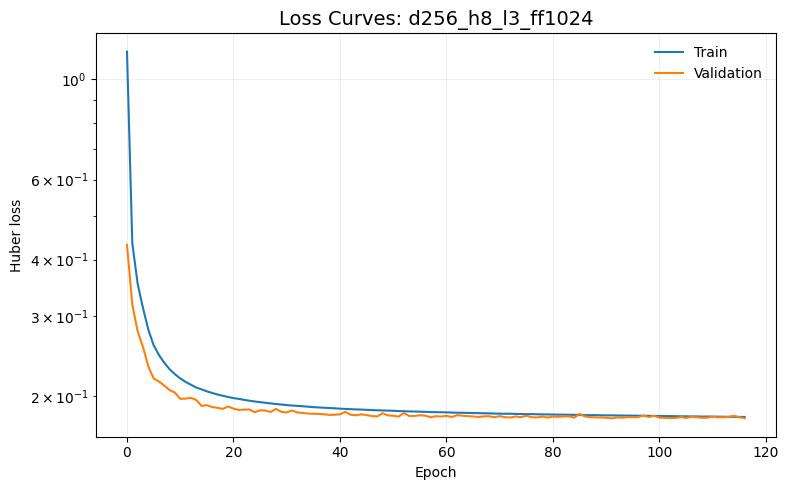

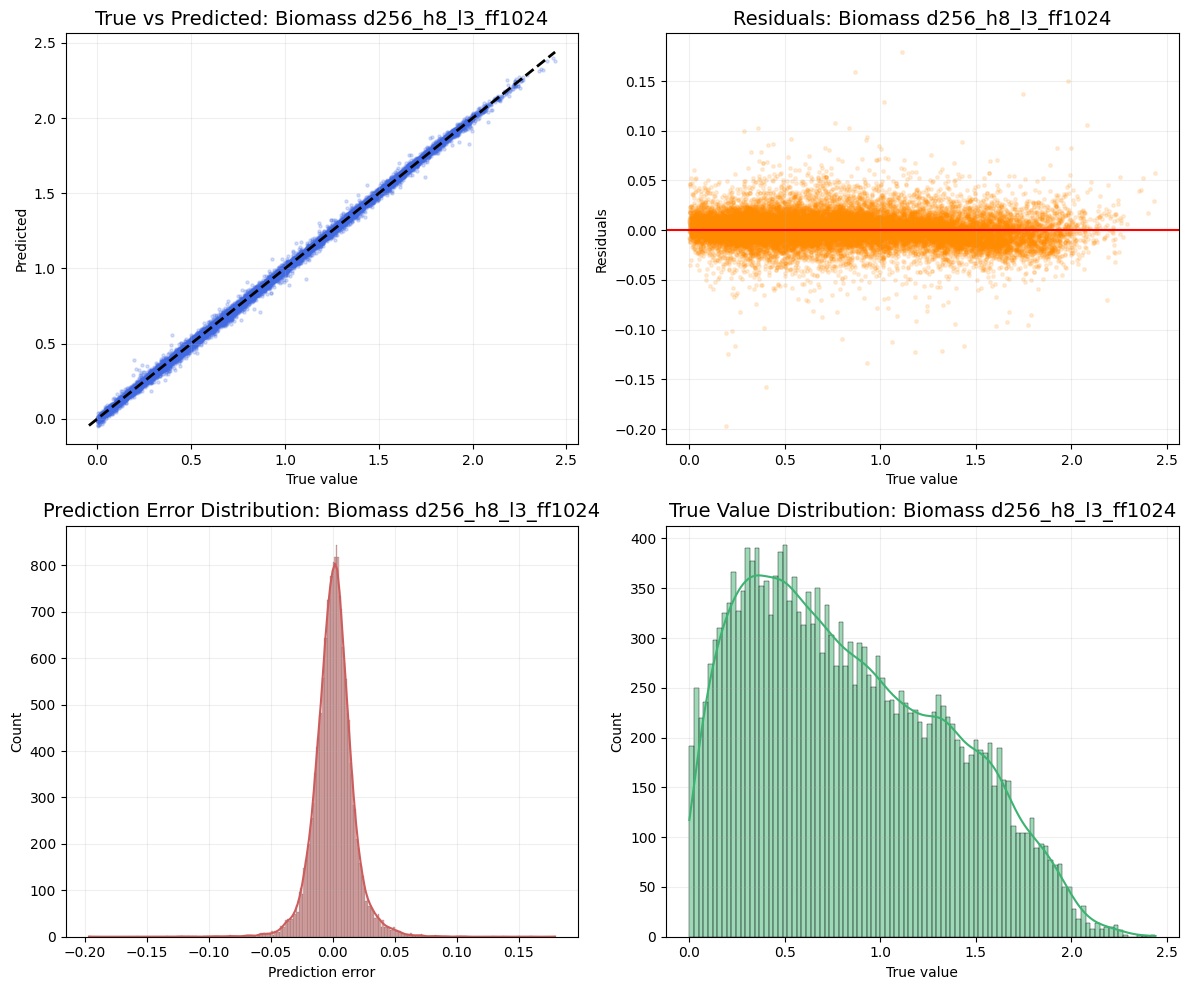

,name,d_model,n_heads,n_layers,d_ff,n_params,best_epoch,best_val_loss,epochs_ran,elapsed_sec,overall_r2,overall_mae,overall_rmse,biomass_r2,biomass_mae,biomass_rmse
0,d32_h4_l2_ff640,32,4,2,640,97582,248,0.256544,250,28137.924446,0.982337,0.387795,1.559937,0.978653,0.047842,0.075814
1,d128_h8_l2_ff640,128,8,2,640,477078,187,0.189484,212,53508.435309,0.987957,0.278610,1.288066,0.996483,0.021238,0.030773
2,d64_h8_l3_ff640,64,8,3,640,308513,152,0.180872,177,50630.256338,0.988036,0.257155,1.283837,0.996712,0.021729,0.029755
3,d64_h8_l4_ff640,64,8,4,640,409324,102,0.180297,127,48089.192041,0.988041,0.254527,1.283606,0.996929,0.020923,0.028755
4,d128_h8_l3_ff640,128,8,3,640,709537,179,0.178809,192,73210.241802,0.987977,0.248456,1.287000,0.998204,0.015349,0.021993
5,d128_h8_l3_ff1024,128,8,3,1024,1007905,190,0.178555,201,98713.044263,0.987966,0.246936,1.287588,0.998691,0.013814,0.018771
6,d128_h8_l4_ff640,128,8,4,640,941996,107,0.178388,116,63297.518159,0.988034,0.247871,1.283937,0.998118,0.015807,0.022513
7,d128_h8_l4_ff1024,128,8,4,1024,1339820,118,0.178233,143,82808.177722,0.988101,0.246746,1.280359,0.998737,0.011941,0.018442
8,d256_h8_l3_ff640,256,8,3,640,1806497,107,0.179311,112,66138.300228,0.987977,0.251683,1.286988,0.998867,0.012733,0.017467
9,d256_h8_l3_ff1024,256,8,3,1024,2399777,92,0.178656,117,79293.650208,0.987960,0.247426,1.287915,0.999039,0.011426,0.016087


d256_h8_l3_ff1024 | overall R2=0.9880 | MAE=0.247426 | RMSE=1.287915 | biomass R2=0.9990
Cooling down for 1.00 hour(s)...


{'name': 'd256_h8_l3_ff1024',
 'd_model': 256,
 'n_heads': 8,
 'n_layers': 3,
 'd_ff': 1024,
 'n_params': 2399777,
 'best_epoch': 92,
 'best_val_loss': 0.17865581374168396,
 'epochs_ran': 117,
 'elapsed_sec': 79293.65020799637,
 'overall_r2': 0.9879600745436192,
 'overall_mae': 0.2474263684051218,
 'overall_rmse': 1.2879150270422075,
 'biomass_r2': 0.9990388751029968,
 'biomass_mae': 0.011425977572798729,
 'biomass_rmse': 0.016086768358945847}

In [16]:
run_model_config(MODEL_CONFIGS[9])  # d256_h8_l3_ff1024

Training d256_h8_l4_ff640
Parameters: 2,400,556
d256_h8_l4_ff640 | epoch 001/250 | train=1.398794 | val=0.402221 | best=0.402221 @ 1 | no_improve=0 | elapsed=00:09:52
d256_h8_l4_ff640 | epoch 002/250 | train=0.391286 | val=0.288746 | best=0.288746 @ 2 | no_improve=0 | elapsed=00:22:35
d256_h8_l4_ff640 | epoch 003/250 | train=0.307221 | val=0.241498 | best=0.241498 @ 3 | no_improve=0 | elapsed=00:35:58
d256_h8_l4_ff640 | epoch 004/250 | train=0.270758 | val=0.222259 | best=0.222259 @ 4 | no_improve=0 | elapsed=00:49:46
d256_h8_l4_ff640 | epoch 005/250 | train=0.250180 | val=0.220247 | best=0.220247 @ 5 | no_improve=0 | elapsed=01:03:48
d256_h8_l4_ff640 | epoch 006/250 | train=0.236897 | val=0.215811 | best=0.215811 @ 6 | no_improve=0 | elapsed=01:17:56
d256_h8_l4_ff640 | epoch 007/250 | train=0.226958 | val=0.202515 | best=0.202515 @ 7 | no_improve=0 | elapsed=01:32:13
d256_h8_l4_ff640 | epoch 008/250 | train=0.219744 | val=0.198931 | best=0.198931 @ 8 | no_improve=0 | elapsed=01:46:25


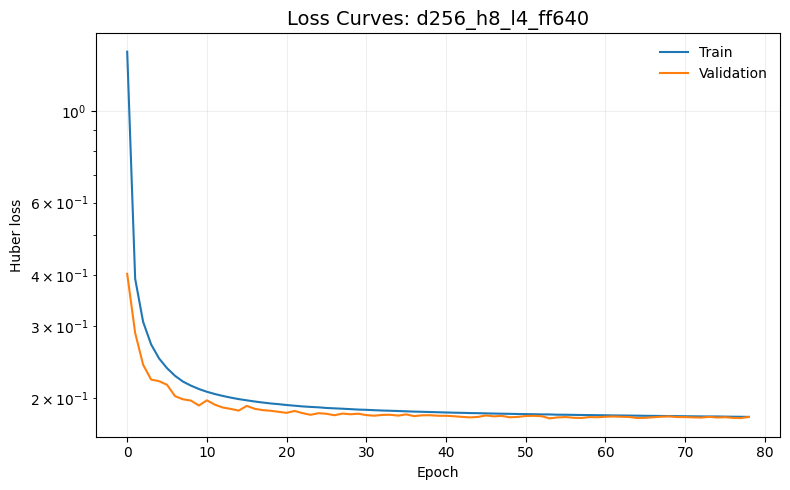

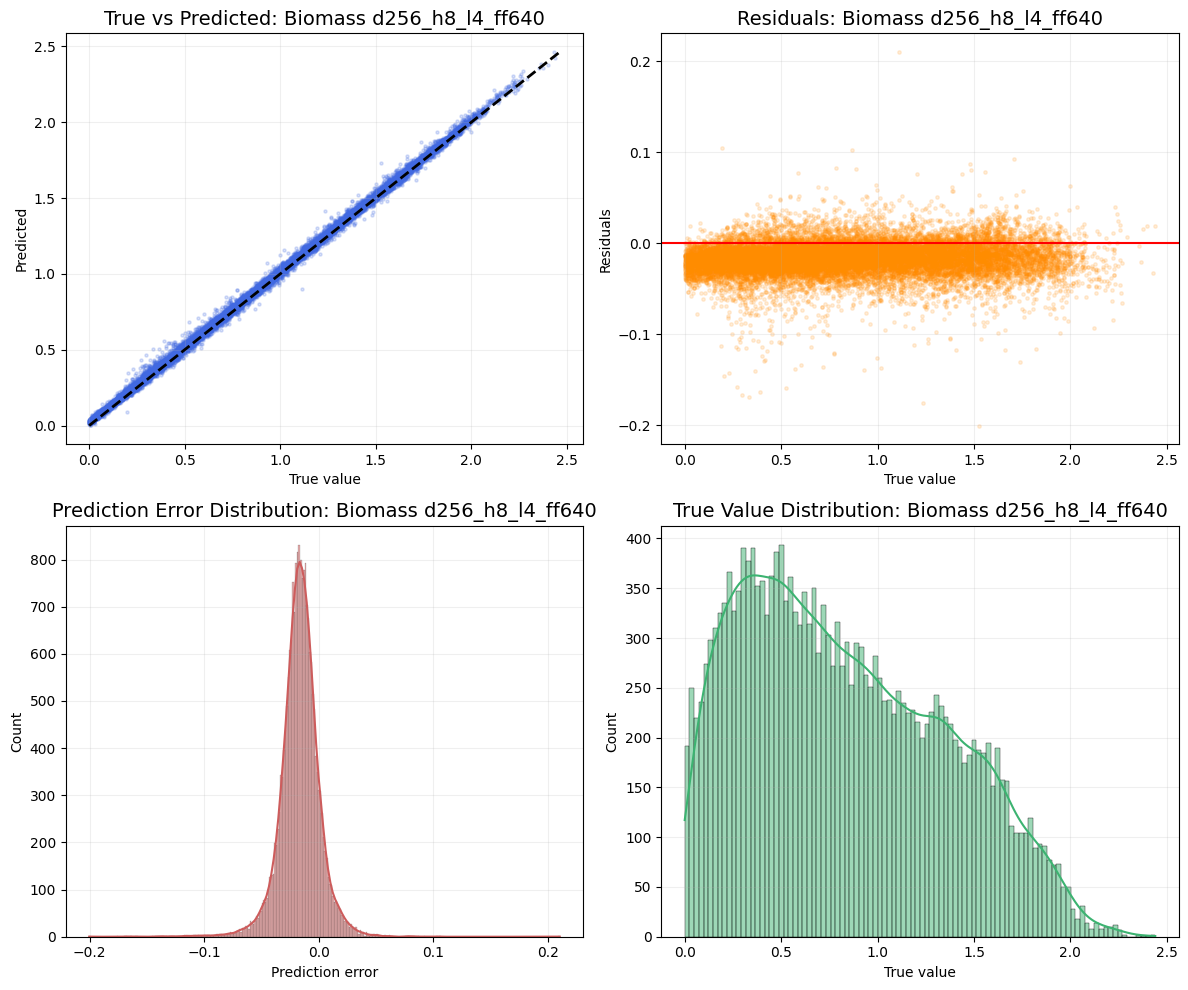

,name,d_model,n_heads,n_layers,d_ff,n_params,best_epoch,best_val_loss,epochs_ran,elapsed_sec,overall_r2,overall_mae,overall_rmse,biomass_r2,biomass_mae,biomass_rmse
0,d32_h4_l2_ff640,32,4,2,640,97582,248,0.256544,250,28137.924446,0.982337,0.387795,1.559937,0.978653,0.047842,0.075814
1,d128_h8_l2_ff640,128,8,2,640,477078,187,0.189484,212,53508.435309,0.987957,0.278610,1.288066,0.996483,0.021238,0.030773
2,d64_h8_l3_ff640,64,8,3,640,308513,152,0.180872,177,50630.256338,0.988036,0.257155,1.283837,0.996712,0.021729,0.029755
3,d64_h8_l4_ff640,64,8,4,640,409324,102,0.180297,127,48089.192041,0.988041,0.254527,1.283606,0.996929,0.020923,0.028755
4,d128_h8_l3_ff640,128,8,3,640,709537,179,0.178809,192,73210.241802,0.987977,0.248456,1.287000,0.998204,0.015349,0.021993
5,d128_h8_l3_ff1024,128,8,3,1024,1007905,190,0.178555,201,98713.044263,0.987966,0.246936,1.287588,0.998691,0.013814,0.018771
6,d128_h8_l4_ff640,128,8,4,640,941996,107,0.178388,116,63297.518159,0.988034,0.247871,1.283937,0.998118,0.015807,0.022513
7,d128_h8_l4_ff1024,128,8,4,1024,1339820,118,0.178233,143,82808.177722,0.988101,0.246746,1.280359,0.998737,0.011941,0.018442
8,d256_h8_l3_ff640,256,8,3,640,1806497,107,0.179311,112,66138.300228,0.987977,0.251683,1.286988,0.998867,0.012733,0.017467
9,d256_h8_l3_ff1024,256,8,3,1024,2399777,92,0.178656,117,79293.650208,0.987960,0.247426,1.287915,0.999039,0.011426,0.016087


d256_h8_l4_ff640 | overall R2=0.9880 | MAE=0.250646 | RMSE=1.283629 | biomass R2=0.9978
Cooling down for 1.00 hour(s)...


{'name': 'd256_h8_l4_ff640',
 'd_model': 256,
 'n_heads': 8,
 'n_layers': 4,
 'd_ff': 640,
 'n_params': 2400556,
 'best_epoch': 54,
 'best_val_loss': 0.1787413294315338,
 'epochs_ran': 79,
 'elapsed_sec': 65418.38907575607,
 'overall_r2': 0.9880400741301583,
 'overall_mae': 0.25064587202143357,
 'overall_rmse': 1.283629103852563,
 'biomass_r2': 0.9978364109992981,
 'biomass_mae': 0.019331909716129303,
 'biomass_rmse': 0.024136047810316086}

In [17]:
run_model_config(MODEL_CONFIGS[10])  # d256_h8_l4_ff640

Training d256_h8_l4_ff1024
Parameters: 3,191,596
d256_h8_l4_ff1024 | epoch 001/250 | train=1.152029 | val=0.341516 | best=0.341516 @ 1 | no_improve=0 | elapsed=00:11:43
d256_h8_l4_ff1024 | epoch 002/250 | train=0.354204 | val=0.256628 | best=0.256628 @ 2 | no_improve=0 | elapsed=00:26:37
d256_h8_l4_ff1024 | epoch 003/250 | train=0.286875 | val=0.232030 | best=0.232030 @ 3 | no_improve=0 | elapsed=00:42:07
d256_h8_l4_ff1024 | epoch 004/250 | train=0.256673 | val=0.221979 | best=0.221979 @ 4 | no_improve=0 | elapsed=00:57:55
d256_h8_l4_ff1024 | epoch 005/250 | train=0.238020 | val=0.209522 | best=0.209522 @ 5 | no_improve=0 | elapsed=01:13:58
d256_h8_l4_ff1024 | epoch 006/250 | train=0.225926 | val=0.204125 | best=0.204125 @ 6 | no_improve=0 | elapsed=01:29:43
d256_h8_l4_ff1024 | epoch 007/250 | train=0.218370 | val=0.198335 | best=0.198335 @ 7 | no_improve=0 | elapsed=01:45:14
d256_h8_l4_ff1024 | epoch 008/250 | train=0.212705 | val=0.196896 | best=0.196896 @ 8 | no_improve=0 | elapsed=

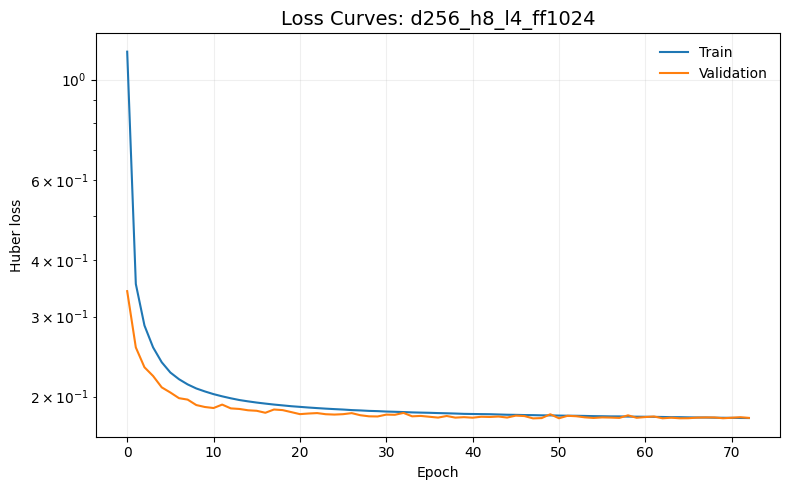

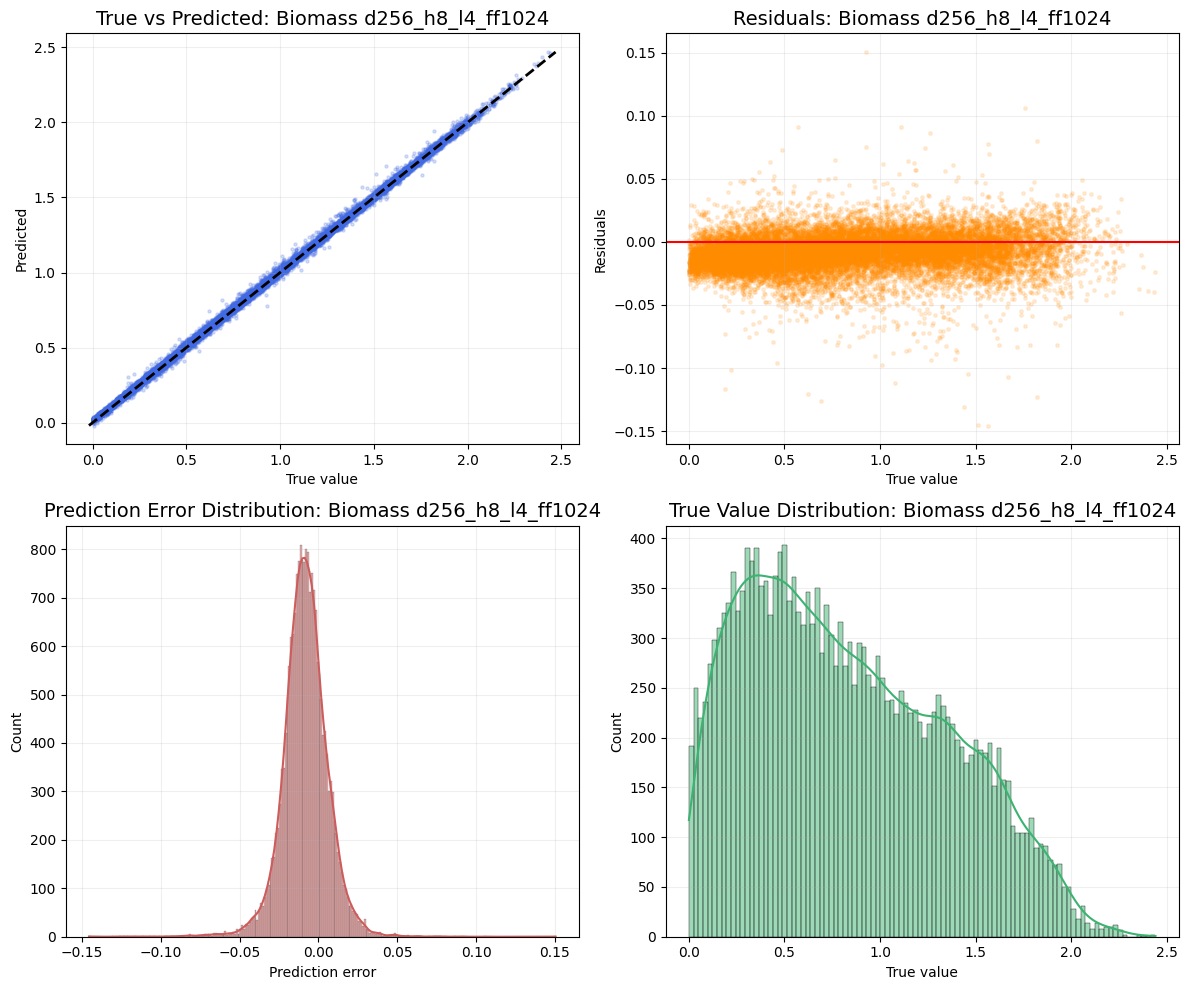

,name,d_model,n_heads,n_layers,d_ff,n_params,best_epoch,best_val_loss,epochs_ran,elapsed_sec,overall_r2,overall_mae,overall_rmse,biomass_r2,biomass_mae,biomass_rmse
0,d32_h4_l2_ff640,32,4,2,640,97582,248,0.256544,250,28137.924446,0.982337,0.387795,1.559937,0.978653,0.047842,0.075814
1,d128_h8_l2_ff640,128,8,2,640,477078,187,0.189484,212,53508.435309,0.987957,0.278610,1.288066,0.996483,0.021238,0.030773
2,d64_h8_l3_ff640,64,8,3,640,308513,152,0.180872,177,50630.256338,0.988036,0.257155,1.283837,0.996712,0.021729,0.029755
3,d64_h8_l4_ff640,64,8,4,640,409324,102,0.180297,127,48089.192041,0.988041,0.254527,1.283606,0.996929,0.020923,0.028755
4,d128_h8_l3_ff640,128,8,3,640,709537,179,0.178809,192,73210.241802,0.987977,0.248456,1.287000,0.998204,0.015349,0.021993
5,d128_h8_l3_ff1024,128,8,3,1024,1007905,190,0.178555,201,98713.044263,0.987966,0.246936,1.287588,0.998691,0.013814,0.018771
6,d128_h8_l4_ff640,128,8,4,640,941996,107,0.178388,116,63297.518159,0.988034,0.247871,1.283937,0.998118,0.015807,0.022513
7,d128_h8_l4_ff1024,128,8,4,1024,1339820,118,0.178233,143,82808.177722,0.988101,0.246746,1.280359,0.998737,0.011941,0.018442
8,d256_h8_l3_ff640,256,8,3,640,1806497,107,0.179311,112,66138.300228,0.987977,0.251683,1.286988,0.998867,0.012733,0.017467
9,d256_h8_l3_ff1024,256,8,3,1024,2399777,92,0.178656,117,79293.650208,0.987960,0.247426,1.287915,0.999039,0.011426,0.016087


d256_h8_l4_ff1024 | overall R2=0.9879 | MAE=0.248896 | RMSE=1.288759 | biomass R2=0.9989
Cooling down for 1.00 hour(s)...


{'name': 'd256_h8_l4_ff1024',
 'd_model': 256,
 'n_heads': 8,
 'n_layers': 4,
 'd_ff': 1024,
 'n_params': 3191596,
 'best_epoch': 48,
 'best_val_loss': 0.17898767228126525,
 'epochs_ran': 73,
 'elapsed_sec': 70087.69153618813,
 'overall_r2': 0.9879442843055022,
 'overall_mae': 0.24889580718092427,
 'overall_rmse': 1.2887592939615227,
 'biomass_r2': 0.9989497661590576,
 'biomass_mae': 0.012881713919341564,
 'biomass_rmse': 0.016816072165966034}

In [18]:
run_model_config(MODEL_CONFIGS[11])  # d256_h8_l4_ff1024

## Model Size Comparison

In [19]:
comparison_cols = [
    "name", "d_model", "n_heads", "n_layers", "d_ff", "n_params",
    "best_epoch", "best_val_loss", "epochs_ran", "elapsed_sec",
    "biomass_r2", "biomass_mae", "biomass_rmse",
    "overall_r2", "overall_mae", "overall_rmse",
]

try:
    comparison_df = pd.DataFrame(sweep_results)
except NameError:
    comparison_df = pd.DataFrame()

if comparison_df.empty and RESULTS_CSV.exists():
    comparison_df = pd.read_csv(RESULTS_CSV)

if comparison_df.empty:
    print("No sweep results available yet. Run the individual model training cells first.")
else:
    expected_names = [config["name"] for config in MODEL_CONFIGS]
    result_names = comparison_df["name"].tolist()
    duplicate_names = comparison_df.loc[comparison_df["name"].duplicated(), "name"].tolist()
    missing_names = [name for name in expected_names if name not in result_names]
    unexpected_names = [name for name in result_names if name not in expected_names]
    if duplicate_names or missing_names or unexpected_names:
        raise RuntimeError(
            "Comparison requires exactly one result for each configured model. "
            f"Missing: {missing_names}; duplicates: {duplicate_names}; "
            f"unexpected: {unexpected_names}"
        )
    comparison_df = comparison_df[comparison_cols]
    metric_cols = [
        "best_val_loss", "biomass_r2", "biomass_mae", "biomass_rmse",
        "overall_r2", "overall_mae", "overall_rmse",
    ]
    if not np.isfinite(comparison_df[metric_cols].to_numpy(dtype=float)).all():
        raise RuntimeError("Comparison metrics contain NaN or infinite values.")
    comparison_df = comparison_df.sort_values("overall_r2", ascending=False).reset_index(drop=True)
    display(comparison_df)
    comparison_df.to_csv(RESULTS_CSV, index=False)
    print(f"Saved final comparison metrics to {RESULTS_CSV}")

,name,d_model,n_heads,n_layers,d_ff,n_params,best_epoch,best_val_loss,epochs_ran,elapsed_sec,biomass_r2,biomass_mae,biomass_rmse,overall_r2,overall_mae,overall_rmse
0,d128_h8_l4_ff1024,128,8,4,1024,1339820,118,0.178233,143,82808.177722,0.998737,0.011941,0.018442,0.988101,0.246746,1.280359
1,d64_h8_l4_ff640,64,8,4,640,409324,102,0.180297,127,48089.192041,0.996929,0.020923,0.028755,0.988041,0.254527,1.283606
2,d256_h8_l4_ff640,256,8,4,640,2400556,54,0.178741,79,65418.389076,0.997836,0.019332,0.024136,0.988040,0.250646,1.283629
3,d64_h8_l3_ff640,64,8,3,640,308513,152,0.180872,177,50630.256338,0.996712,0.021729,0.029755,0.988036,0.257155,1.283837
4,d128_h8_l4_ff640,128,8,4,640,941996,107,0.178388,116,63297.518159,0.998118,0.015807,0.022513,0.988034,0.247871,1.283937
5,d256_h8_l3_ff640,256,8,3,640,1806497,107,0.179311,112,66138.300228,0.998867,0.012733,0.017467,0.987977,0.251683,1.286988
6,d128_h8_l3_ff640,128,8,3,640,709537,179,0.178809,192,73210.241802,0.998204,0.015349,0.021993,0.987977,0.248456,1.287000
7,d128_h8_l3_ff1024,128,8,3,1024,1007905,190,0.178555,201,98713.044263,0.998691,0.013814,0.018771,0.987966,0.246936,1.287588
8,d256_h8_l3_ff1024,256,8,3,1024,2399777,92,0.178656,117,79293.650208,0.999039,0.011426,0.016087,0.987960,0.247426,1.287915
9,d128_h8_l2_ff640,128,8,2,640,477078,187,0.189484,212,53508.435309,0.996483,0.021238,0.030773,0.987957,0.278610,1.288066


Saved final comparison metrics to insights\ecoli_core_architecture_sweep\model_size_comparison.csv


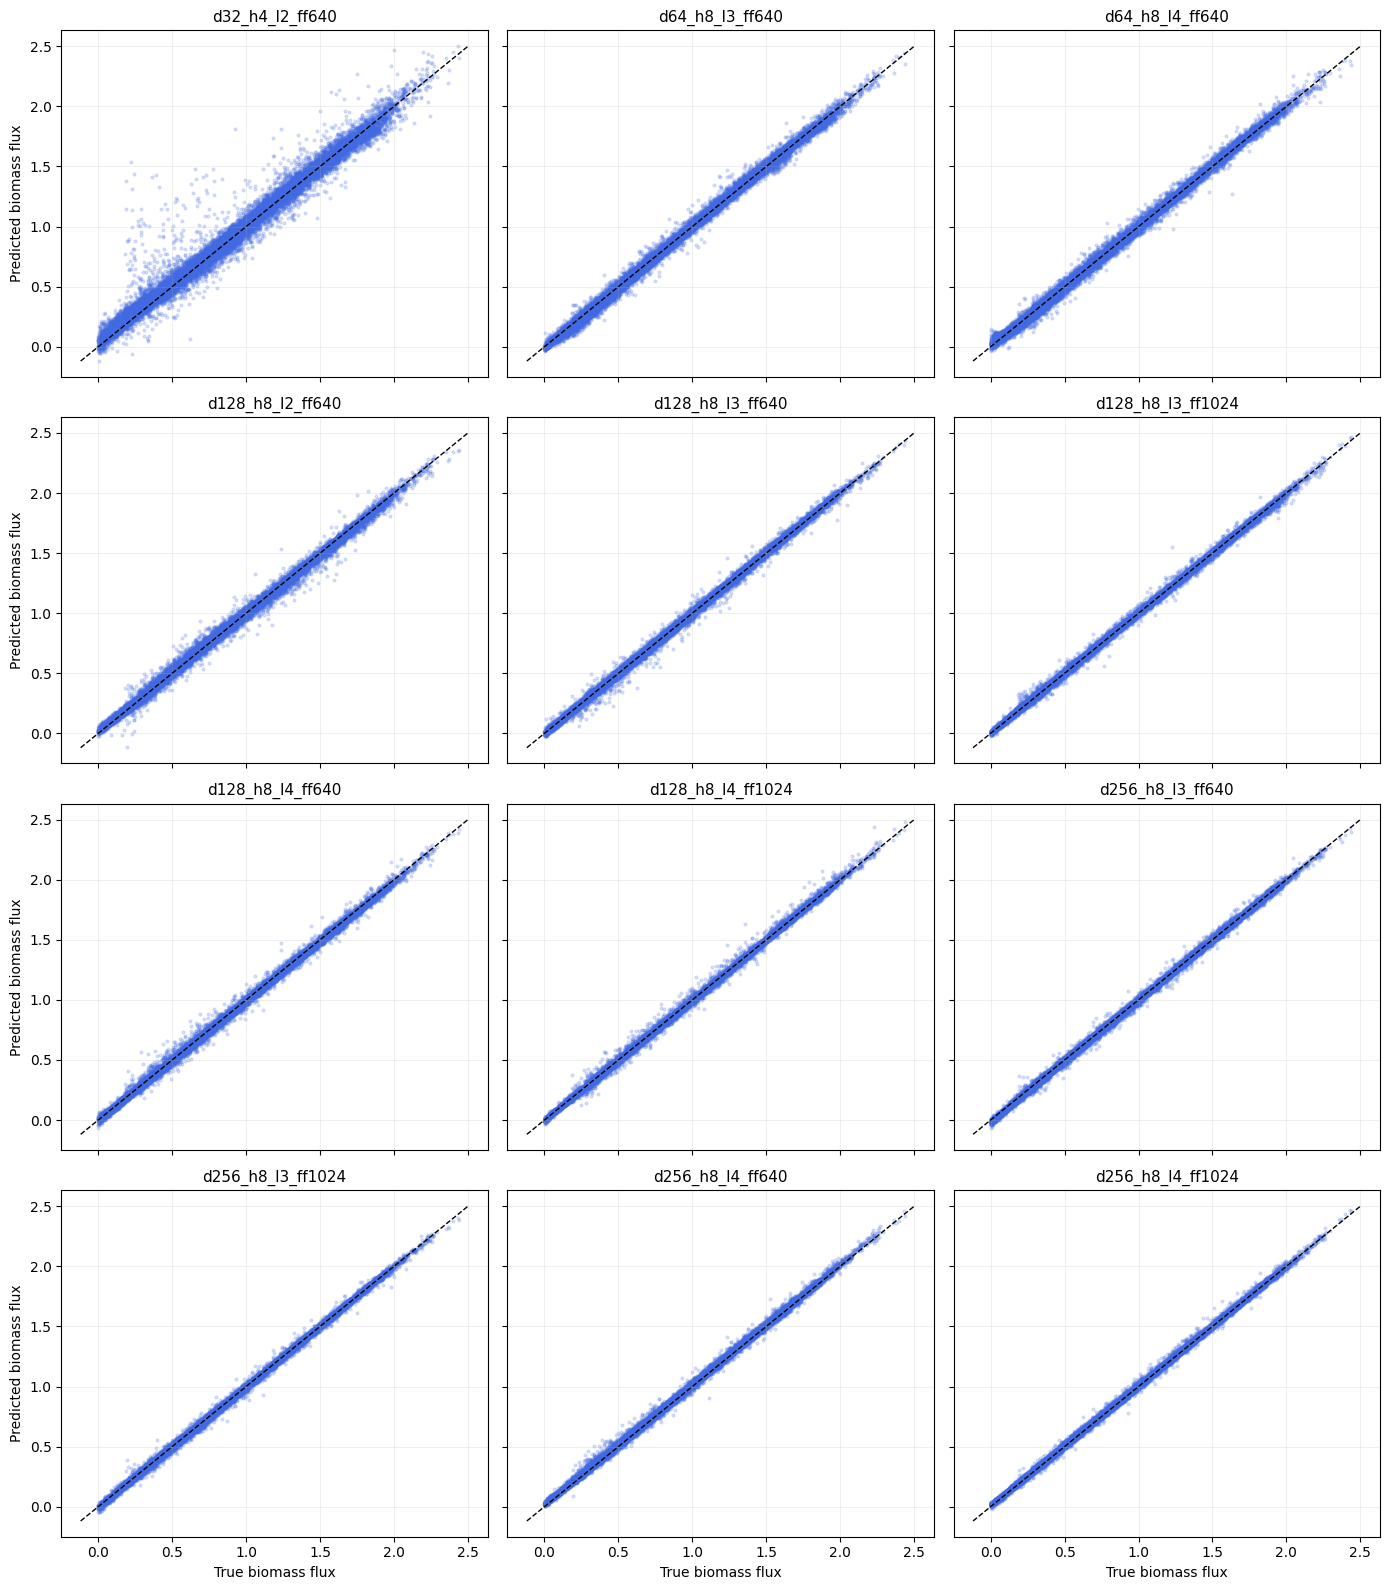

Saved biomass panel comparison to pics\2026-07-14\ecoli_core_architecture_sweep\biomass_flux_model_size_panels.png


In [20]:
try:
    biomass_panels
except NameError:
    biomass_panels = {}

# Plot from small to large, using d_model as the primary ordering key.
plot_configs = sorted(
    MODEL_CONFIGS,
    key=lambda config: (
        config["d_model"],
        config["n_layers"],
        config["d_ff"],
        config["n_heads"],
    ),
)
expected_names = [config["name"] for config in plot_configs]
missing_names = [name for name in expected_names if name not in biomass_panels]
if missing_names:
    raise RuntimeError(
        "Run all individual model training cells before plotting biomass panels. "
        f"Missing models: {missing_names}"
    )

reference_true = biomass_panels[expected_names[0]]["true"]
for name in expected_names:
    panel = biomass_panels[name]
    if panel["true"].shape != panel["pred"].shape:
        raise RuntimeError(f"Biomass true/predicted shape mismatch for {name}.")
    if panel["true"].shape != reference_true.shape or not np.array_equal(panel["true"], reference_true):
        raise RuntimeError(f"Biomass test targets do not match across models; mismatch at {name}.")
    if not np.isfinite(panel["true"]).all() or not np.isfinite(panel["pred"]).all():
        raise RuntimeError(f"Biomass panel contains NaN or infinite values for {name}.")

fig, axes = plt.subplots(4, 3, figsize=(14, 16), sharex=True, sharey=True)
axes = axes.ravel()

global_lo = min(
    min(float(np.min(biomass_panels[name]["true"])), float(np.min(biomass_panels[name]["pred"])))
    for name in expected_names
)
global_hi = max(
    max(float(np.max(biomass_panels[name]["true"])), float(np.max(biomass_panels[name]["pred"])))
    for name in expected_names
)

rng = np.random.default_rng(SEED)
if BIOMASS_PANEL_SAMPLE_COUNT is not None and len(reference_true) > BIOMASS_PANEL_SAMPLE_COUNT:
    panel_indices = rng.choice(len(reference_true), size=BIOMASS_PANEL_SAMPLE_COUNT, replace=False)
else:
    panel_indices = None

for ax, config in zip(axes, plot_configs):
    name = config["name"]
    y_true_panel = biomass_panels[name]["true"]
    y_pred_panel = biomass_panels[name]["pred"]

    if panel_indices is not None:
        x_plot = y_true_panel[panel_indices]
        y_plot = y_pred_panel[panel_indices]
    else:
        x_plot = y_true_panel
        y_plot = y_pred_panel

    ax.scatter(x_plot, y_plot, alpha=0.18, s=4, color="royalblue", rasterized=True)
    ax.plot([global_lo, global_hi], [global_lo, global_hi], color="black", linestyle="--", linewidth=1)
    ax.set_title(name, fontsize=11)
    ax.grid(alpha=0.2)

for ax in axes[-3:]:
    ax.set_xlabel("True biomass flux")
for ax in axes[::3]:
    ax.set_ylabel("Predicted biomass flux")

for ax in axes[len(plot_configs):]:
    ax.set_visible(False)

fig.tight_layout()
out_path = PLOT_DIR / "biomass_flux_model_size_panels.png"
fig.savefig(out_path, dpi=250, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved biomass panel comparison to {out_path}")